In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
file_path = '/content/drive/MyDrive/Colab Notebooks/CTONI_Raw_Data.xlsx'

In [40]:
file_path = '/content/drive/MyDrive/Colab Notebooks/PCA_Raw_Data.xlsx'

In [41]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Main Data File.csv'

In [42]:
# ============================================================
# CRJ REVISION
# STEP 1 — SAMPLE-SPECIFIC RELIABILITY
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# File locations
# ------------------------------------------------------------

CTONI_PATH = "/content/drive/MyDrive/Colab Notebooks/CTONI_Raw_Data.xlsx"
PCA_PATH   = "/content/drive/MyDrive/Colab Notebooks/PCA_Raw_Data.xlsx"
MAIN_PATH  = "/content/drive/MyDrive/Colab Notebooks/Main Data File.csv"

# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

ctoni = pd.read_excel(CTONI_PATH)
pca   = pd.read_excel(PCA_PATH)
main  = pd.read_csv(MAIN_PATH)

# ------------------------------------------------------------
# Basic information
# ------------------------------------------------------------

print("=" * 60)
print("FILES LOADED SUCCESSFULLY")
print("=" * 60)

print(f"CTONI raw data : {ctoni.shape[0]} rows × {ctoni.shape[1]} columns")
print(f"PCA raw data   : {pca.shape[0]} rows × {pca.shape[1]} columns")
print(f"Main data      : {main.shape[0]} rows × {main.shape[1]} columns")

print("\nMAIN DATA VARIABLES:")
print(main.columns.tolist())

print("\nFirst 5 rows of Main Data:")
display(main.head())

FILES LOADED SUCCESSFULLY
CTONI raw data : 1589 rows × 319 columns
PCA raw data   : 993 rows × 335 columns
Main data      : 682 rows × 12 columns

MAIN DATA VARIABLES:
['Grade', 'Age', 'Gender', 'PCI', 'GCI', 'IQ', 'PCAdrawstn', 'PCAcatestn', 'PCASumStn', 'CIndex', 'Parerating', 'Teachrating']

First 5 rows of Main Data:


,Grade,Age,Gender,PCI,GCI,IQ,PCAdrawstn,PCAcatestn,PCASumStn,CIndex,Parerating,Teachrating
0,1,6,1,102.05,93.34,98.0,8.42,7.89,16.31,88.0,123.0,120.0
1,1,6,1,99.48,89.50,94.0,9.26,7.58,16.84,90.0,11.0,74.0
2,1,6,1,91.64,95.65,93.0,6.33,5.46,11.79,74.0,114.0,90.0
3,1,6,1,95.81,106.97,102.0,8.00,9.10,17.10,91.0,126.0,114.0
4,1,6,1,93.40,95.55,94.0,7.17,8.80,15.97,87.0,122.0,97.0


In [43]:
# ============================================================
# STEP 1B — CLEAN AND VALIDATE CTONI ITEM DATA
# ============================================================

# Six 25-item CTONI blocks identified from the raw file
ctoni_blocks = {
    "Block1": list(ctoni.columns[164:189]),
    "Block2": list(ctoni.columns[190:215]),
    "Block3": list(ctoni.columns[216:241]),
    "Block4": list(ctoni.columns[242:267]),
    "Block5": list(ctoni.columns[268:293]),
    "Block6": list(ctoni.columns[294:319])
}

# ------------------------------------------------------------
# 1. Check number of items in each block
# ------------------------------------------------------------

print("=" * 70)
print("CTONI ITEM BLOCK VALIDATION")
print("=" * 70)

for block, cols in ctoni_blocks.items():
    print(f"{block}: {len(cols)} items")


# ------------------------------------------------------------
# 2. Convert each block to numeric and check scoring
#    Valid CTONI item responses must be 0 or 1
# ------------------------------------------------------------

validation_results = []

for block, cols in ctoni_blocks.items():

    x = ctoni[cols].apply(pd.to_numeric, errors="coerce")

    # Identify values other than 0/1
    invalid_mask = (~x.isin([0, 1])) & x.notna()

    n_invalid = int(invalid_mask.sum().sum())

    observed = sorted(
        pd.unique(
            x.to_numpy().ravel()[
                ~pd.isna(x.to_numpy().ravel())
            ]
        )
    )

    validation_results.append({
        "Block": block,
        "Items": len(cols),
        "Rows_with_data": int(x.notna().any(axis=1).sum()),
        "Invalid_cells": n_invalid,
        "Observed_values": str(observed)
    })

validation_table = pd.DataFrame(validation_results)

display(validation_table)


# ------------------------------------------------------------
# 3. Print exact location of any invalid values
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("INVALID CTONI RESPONSES")
print("=" * 70)

total_invalid = 0

for block, cols in ctoni_blocks.items():

    x = ctoni[cols].apply(pd.to_numeric, errors="coerce")

    invalid_mask = (~x.isin([0, 1])) & x.notna()

    rows, columns = np.where(invalid_mask)

    for r, c in zip(rows, columns):

        total_invalid += 1

        print(
            f"{block} | "
            f"row={x.index[r]} | "
            f"column={cols[c]} | "
            f"value={x.iloc[r, c]}"
        )

if total_invalid == 0:
    print("No invalid responses detected.")


# ------------------------------------------------------------
# 4. Create CLEAN copies
#
# Invalid values are set to NaN.
# IMPORTANT: We do NOT automatically change values such as
# 10 to 1 because that would assume the intended response.
# ------------------------------------------------------------

ctoni_clean_blocks = {}

for block, cols in ctoni_blocks.items():

    x = ctoni[cols].apply(pd.to_numeric, errors="coerce")

    # Retain only legitimate binary responses
    x = x.where(x.isin([0, 1]))

    ctoni_clean_blocks[block] = x


# ------------------------------------------------------------
# 5. Check missingness after cleaning
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CTONI CLEANING SUMMARY")
print("=" * 70)

summary = []

for block, x in ctoni_clean_blocks.items():

    summary.append({
        "Block": block,
        "Items": x.shape[1],
        "Rows": x.shape[0],
        "Complete_rows": int(x.notna().all(axis=1).sum()),
        "Rows_with_any_data": int(x.notna().any(axis=1).sum()),
        "Missing_cells": int(x.isna().sum().sum())
    })

cleaning_summary = pd.DataFrame(summary)

display(cleaning_summary)

CTONI ITEM BLOCK VALIDATION
Block1: 25 items
Block2: 25 items
Block3: 25 items
Block4: 25 items
Block5: 25 items
Block6: 25 items


,Block,Items,Rows_with_data,Invalid_cells,Observed_values
0,Block1,25,1588,0,"[np.float64(0.0), np.float64(1.0)]"
1,Block2,25,1588,0,"[np.float64(0.0), np.float64(1.0)]"
2,Block3,25,1588,0,"[np.float64(0.0), np.float64(1.0)]"
3,Block4,25,1588,0,"[np.float64(0.0), np.float64(1.0)]"
4,Block5,25,1588,1,"[np.float64(0.0), np.float64(1.0), np.float64(..."
5,Block6,25,1588,0,"[np.float64(0.0), np.float64(1.0)]"



INVALID CTONI RESPONSES
Block5 | row=865 | column=CTONI.115 | value=10.0

CTONI CLEANING SUMMARY


,Block,Items,Rows,Complete_rows,Rows_with_any_data,Missing_cells
0,Block1,25,1589,1587,1588,26
1,Block2,25,1589,1588,1588,25
2,Block3,25,1589,1588,1588,25
3,Block4,25,1589,1586,1588,27
4,Block5,25,1589,1587,1588,26
5,Block6,25,1589,1588,1588,25


In [44]:
# ============================================================
# STEP 1C — CTONI SAMPLE-SPECIFIC RELIABILITY
# KR-20 / Cronbach's alpha for binary items
# ============================================================

def cronbach_alpha_binary(x):
    """
    Cronbach's alpha for binary (0/1) items.
    For dichotomous items this is equivalent to KR-20.

    Complete cases are used within each subtest.
    """

    x = x.dropna()

    n = len(x)
    k = x.shape[1]

    if n < 2 or k < 2:
        return np.nan, n

    item_variances = x.var(axis=0, ddof=1)
    total_scores = x.sum(axis=1)
    total_variance = total_scores.var(ddof=1)

    if total_variance == 0:
        return np.nan, n

    alpha = (k / (k - 1)) * (
        1 - item_variances.sum() / total_variance
    )

    return alpha, n


# ------------------------------------------------------------
# Calculate reliability for each CTONI block
# ------------------------------------------------------------

results = []

for block, x in ctoni_clean_blocks.items():

    alpha, n = cronbach_alpha_binary(x)

    results.append({
        "CTONI_Subtest": block,
        "Number_of_Items": x.shape[1],
        "N": n,
        "KR20_Alpha": alpha
    })


ctoni_reliability = pd.DataFrame(results)

print("=" * 70)
print("CTONI SAMPLE-SPECIFIC INTERNAL CONSISTENCY")
print("=" * 70)

display(
    ctoni_reliability.style.format({
        "KR20_Alpha": "{:.3f}"
    })
)

CTONI SAMPLE-SPECIFIC INTERNAL CONSISTENCY


,CTONI_Subtest,Number_of_Items,N,KR20_Alpha
0,Block1,25,1587,0.960
1,Block2,25,1588,0.967
2,Block3,25,1588,0.959
3,Block4,25,1586,0.969
4,Block5,25,1587,0.968
5,Block6,25,1588,0.968


In [45]:
# ============================================================
# IDENTIFY THE SIX CTONI SUBTEST BLOCKS FROM RAW HEADERS
# ============================================================

for i in range(160, 319):
    col = ctoni.columns[i]

    # first few raw values
    vals = ctoni[col].head(3).tolist()

    print(
        f"{i:3d} | {str(col):15s} | "
        f"row0={vals[0] if len(vals)>0 else None} | "
        f"row1={vals[1] if len(vals)>1 else None}"
    )

160 | TO1A.156        | row0=5th12 | row1=0
161 | TO1A.157        | row0=5th13 | row1=0
162 | TO1A.158        | row0=5th14 | row1=0
163 | 0.4             | row0=0.0 | row1=0.0
164 | CTONI           | row0=1st1 | row1=1
165 | CTONI.1         | row0=1st2 | row1=1
166 | CTONI.2         | row0=1st3 | row1=1
167 | CTONI.3         | row0=1st4 | row1=1
168 | CTONI.4         | row0=1st5 | row1=1
169 | CTONI.5         | row0=1st6 | row1=1
170 | CTONI.6         | row0=1st7 | row1=1
171 | CTONI.7         | row0=1st8 | row1=1
172 | CTONI.8         | row0=1st9 | row1=1
173 | CTONI.9         | row0=1st10 | row1=1
174 | CTONI.10        | row0=1st11 | row1=1
175 | CTONI.11        | row0=1st12 | row1=0
176 | CTONI.12        | row0=1st13 | row1=1
177 | CTONI.13        | row0=1st14 | row1=1
178 | CTONI.14        | row0=1st15 | row1=1
179 | CTONI.15        | row0=1st16 | row1=0
180 | CTONI.16        | row0=1st17 | row1=1
181 | CTONI.17        | row0=1st18 | row1=0
182 | CTONI.18        | row0=1st19 | row1

In [46]:
# Show the first-row labels for each of our six blocks

for block_name, cols in ctoni_blocks.items():

    print("\n" + "=" * 60)
    print(block_name)
    print("=" * 60)

    for col in cols:
        print(
            f"{col:12s} -> "
            f"{ctoni.loc[0, col]}"
        )


Block1
CTONI        -> 1st1
CTONI.1      -> 1st2
CTONI.2      -> 1st3
CTONI.3      -> 1st4
CTONI.4      -> 1st5
CTONI.5      -> 1st6
CTONI.6      -> 1st7
CTONI.7      -> 1st8
CTONI.8      -> 1st9
CTONI.9      -> 1st10
CTONI.10     -> 1st11
CTONI.11     -> 1st12
CTONI.12     -> 1st13
CTONI.13     -> 1st14
CTONI.14     -> 1st15
CTONI.15     -> 1st16
CTONI.16     -> 1st17
CTONI.17     -> 1st18
CTONI.18     -> 1st19
CTONI.19     -> 1st20
CTONI.20     -> 1st21
CTONI.21     -> 1st22
CTONI.22     -> 1st23
CTONI.23     -> 1st24
CTONI.24     -> 1st25

Block2
CTONI.25     -> 2nd1
CTONI.26     -> 2nd2
CTONI.27     -> 2nd3
CTONI.28     -> 2nd4
CTONI.29     -> 2nd5
CTONI.30     -> 2nd6
CTONI.31     -> 2nd7
CTONI.32     -> 2nd8
CTONI.33     -> 2nd9
CTONI.34     -> 2nd10
CTONI.35     -> 2nd11
CTONI.36     -> 2nd12
CTONI.37     -> 2nd13
CTONI.38     -> 2nd14
CTONI.39     -> 2nd15
CTONI.40     -> 2nd16
CTONI.41     -> 2nd17
CTONI.42     -> 2nd18
CTONI.43     -> 2nd19
CTONI.44     -> 2nd20
CTONI.45    

In [47]:
boundaries = [
    (160, 192),
    (186, 218),
    (212, 244),
    (238, 270),
    (264, 296),
    (290, 319)
]

for start, end in boundaries:

    print("\n", "=" * 70)

    for i in range(start, min(end, len(ctoni.columns))):
        col = ctoni.columns[i]

        print(
            i,
            "|",
            col,
            "| first value:",
            ctoni.iloc[0, i]
        )


160 | TO1A.156 | first value: 5th12
161 | TO1A.157 | first value: 5th13
162 | TO1A.158 | first value: 5th14
163 | 0.4 | first value: 0.0
164 | CTONI | first value: 1st1
165 | CTONI.1 | first value: 1st2
166 | CTONI.2 | first value: 1st3
167 | CTONI.3 | first value: 1st4
168 | CTONI.4 | first value: 1st5
169 | CTONI.5 | first value: 1st6
170 | CTONI.6 | first value: 1st7
171 | CTONI.7 | first value: 1st8
172 | CTONI.8 | first value: 1st9
173 | CTONI.9 | first value: 1st10
174 | CTONI.10 | first value: 1st11
175 | CTONI.11 | first value: 1st12
176 | CTONI.12 | first value: 1st13
177 | CTONI.13 | first value: 1st14
178 | CTONI.14 | first value: 1st15
179 | CTONI.15 | first value: 1st16
180 | CTONI.16 | first value: 1st17
181 | CTONI.17 | first value: 1st18
182 | CTONI.18 | first value: 1st19
183 | CTONI.19 | first value: 1st20
184 | CTONI.20 | first value: 1st21
185 | CTONI.21 | first value: 1st22
186 | CTONI.22 | first value: 1st23
187 | CTONI.23 | first value: 1st24
188 | CTONI.24 | fi

In [48]:
# ============================================================
# STEP 1D — FINAL CTONI RELIABILITY USING TEMPORARY BLOCK NAMES
# ============================================================

# Function for KR-20 / Cronbach's alpha
def kr20_alpha(x):
    x = x.apply(pd.to_numeric, errors="coerce")

    # CTONI responses must be binary
    x = x.where(x.isin([0, 1]))

    # Complete cases
    complete = x.dropna()

    n = len(complete)
    k = complete.shape[1]

    if n < 2 or k < 2:
        return np.nan, n

    item_variances = complete.var(axis=0, ddof=1)
    total_scores = complete.sum(axis=1)
    total_variance = total_scores.var(ddof=1)

    alpha = (k / (k - 1)) * (
        1 - item_variances.sum() / total_variance
    )

    return alpha, n


# ------------------------------------------------------------
# 1. Reliability for six CTONI blocks
# ------------------------------------------------------------

results = []

for block, cols in ctoni_blocks.items():

    x = ctoni[cols]

    alpha, n = kr20_alpha(x)

    results.append({
        "Scale": block,
        "Items": len(cols),
        "N": n,
        "KR20_Alpha": alpha
    })


# ------------------------------------------------------------
# 2. Reliability for ALL 150 CTONI items
# ------------------------------------------------------------

all_ctoni_cols = []

for cols in ctoni_blocks.values():
    all_ctoni_cols.extend(cols)

overall_alpha, overall_n = kr20_alpha(
    ctoni[all_ctoni_cols]
)

results.append({
    "Scale": "Overall CTONI (Blocks 1–6)",
    "Items": len(all_ctoni_cols),
    "N": overall_n,
    "KR20_Alpha": overall_alpha
})


# ------------------------------------------------------------
# 3. Final table
# ------------------------------------------------------------

ctoni_final_reliability = pd.DataFrame(results)

print("=" * 70)
print("CTONI INTERNAL CONSISTENCY RELIABILITY")
print("=" * 70)

display(
    ctoni_final_reliability.style.format({
        "KR20_Alpha": "{:.3f}"
    })
)

CTONI INTERNAL CONSISTENCY RELIABILITY


,Scale,Items,N,KR20_Alpha
0,Block1,25,1587,0.960
1,Block2,25,1588,0.967
2,Block3,25,1588,0.959
3,Block4,25,1586,0.969
4,Block5,25,1587,0.968
5,Block6,25,1588,0.968
6,Overall CTONI (Blocks 1–6),150,1584,0.993


In [49]:
ctoni_final_reliability.to_csv(
    "CTONI_reliability_results.csv",
    index=False
)

print("CTONI reliability results saved.")

CTONI reliability results saved.


In [50]:
# ============================================================
# STEP 1E — PCA DRAWING RELIABILITY
# Construct 8 drawing-task scores from 4 components per task
# ============================================================

# Columns 214:246 = 8 tasks × 4 scoring components
pca_drawing_cols = list(pca.columns[214:246])

drawing_tasks = pd.DataFrame(index=pca.index)

for task in range(8):

    cols = pca_drawing_cols[task*4:(task+1)*4]

    x = pca[cols].apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Only legitimate PCA component scores
    x = x.where(x.isin([0, 1, 2]))

    # Require all 4 components to calculate task score
    drawing_tasks[f"Drawing_{task+1}"] = x.sum(
        axis=1,
        min_count=4
    )

print("=" * 70)
print("PCA DRAWING TASK SCORES")
print("=" * 70)

display(drawing_tasks.head(10))

print("\nTask score ranges:")

for col in drawing_tasks.columns:
    print(
        col,
        "| N =", drawing_tasks[col].notna().sum(),
        "| Min =", drawing_tasks[col].min(),
        "| Max =", drawing_tasks[col].max(),
        "| Mean =", round(drawing_tasks[col].mean(), 2)
    )

PCA DRAWING TASK SCORES


,Drawing_1,Drawing_2,Drawing_3,Drawing_4,Drawing_5,Drawing_6,Drawing_7,Drawing_8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5.0,2.0,3.0,2.0,2.0,2.0,1.0,0.0
2,3.0,2.0,3.0,1.0,1.0,1.0,1.0,2.0
3,0.0,3.0,3.0,3.0,2.0,3.0,4.0,2.0
4,3.0,2.0,3.0,3.0,3.0,0.0,1.0,2.0
5,0.0,2.0,3.0,0.0,0.0,2.0,0.0,0.0
6,3.0,2.0,4.0,2.0,3.0,0.0,2.0,3.0
7,1.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0
8,0.0,3.0,3.0,2.0,0.0,6.0,4.0,2.0
9,6.0,5.0,6.0,5.0,2.0,1.0,5.0,3.0



Task score ranges:
Drawing_1 | N = 985 | Min = 0.0 | Max = 7.0 | Mean = 1.56
Drawing_2 | N = 985 | Min = 0.0 | Max = 7.0 | Mean = 1.52
Drawing_3 | N = 985 | Min = 0.0 | Max = 6.0 | Mean = 1.01
Drawing_4 | N = 985 | Min = 0.0 | Max = 7.0 | Mean = 1.28
Drawing_5 | N = 985 | Min = 0.0 | Max = 8.0 | Mean = 1.05
Drawing_6 | N = 985 | Min = 0.0 | Max = 8.0 | Mean = 1.08
Drawing_7 | N = 985 | Min = 0.0 | Max = 7.0 | Mean = 1.25
Drawing_8 | N = 985 | Min = 0.0 | Max = 6.0 | Mean = 1.58


In [51]:
# ============================================================
# PCA DRAWING — Cronbach's alpha across 8 drawing tasks
# ============================================================

def cronbach_alpha(x):

    x = x.apply(pd.to_numeric, errors="coerce")
    complete = x.dropna()

    n = len(complete)
    k = complete.shape[1]

    if n < 2 or k < 2:
        return np.nan, n

    item_variances = complete.var(axis=0, ddof=1)
    total_variance = complete.sum(axis=1).var(ddof=1)

    if total_variance == 0:
        return np.nan, n

    alpha = (
        k / (k - 1)
    ) * (
        1 - item_variances.sum() / total_variance
    )

    return alpha, n


drawing_alpha, drawing_n = cronbach_alpha(
    drawing_tasks
)

print("=" * 70)
print("PCA DRAWING RELIABILITY")
print("=" * 70)

print(f"Number of drawing tasks : {drawing_tasks.shape[1]}")
print(f"Complete N              : {drawing_n}")
print(f"Cronbach's alpha        : {drawing_alpha:.3f}")

PCA DRAWING RELIABILITY
Number of drawing tasks : 8
Complete N              : 985
Cronbach's alpha        : 0.813


In [52]:
# ============================================================
# STEP 1G — INSPECT REMAINING PCA SCORE BLOCKS
# Using neutral labels until scoring structure is confirmed
# ============================================================

# Inspect columns after Task Set A and before PCAT
for i in range(246, 261):

    col = pca.columns[i]
    x = pd.to_numeric(pca[col], errors="coerce")

    values = sorted(x.dropna().unique())

    print(
        f"{i:3d} | {str(col):20s} | "
        f"N={x.notna().sum():4d} | "
        f"Min={x.min()} | "
        f"Max={x.max()} | "
        f"Unique={len(values)}"
    )

246 | Unnamed: 246         | N= 990 | Min=0.0 | Max=47.0 | Unique=38
247 | Unnamed: 247         | N= 990 | Min=0.0 | Max=16.0 | Unique=17
248 | Unnamed: 248         | N= 990 | Min=0.0 | Max=9.0 | Unique=10
249 | Unnamed: 249         | N= 990 | Min=0.0 | Max=16.0 | Unique=13
250 | Unnamed: 250         | N= 990 | Min=0.0 | Max=16.0 | Unique=17
251 | Unnamed: 251         | N=   0 | Min=nan | Max=nan | Unique=0
252 | PCA Ani1.1           | N= 982 | Min=0.0 | Max=20.0 | Unique=18
253 | Unnamed: 253         | N= 982 | Min=0.0 | Max=12.0 | Unique=13
254 | Unnamed: 254         | N= 982 | Min=0.0 | Max=35.0 | Unique=26
255 | PCA 2ig.1            | N= 978 | Min=0.0 | Max=17.0 | Unique=16
256 | Unnamed: 256         | N= 978 | Min=0.0 | Max=12.0 | Unique=12
257 | Unnamed: 257         | N= 975 | Min=0.0 | Max=29.0 | Unique=26
258 | Unnamed: 258         | N= 319 | Min=0.0 | Max=29.0 | Unique=26
259 | Unnamed: 259         | N= 319 | Min=0.0 | Max=20.0 | Unique=20
260 | Unnamed: 260         | N= 990 |

In [53]:
# ============================================================
# CORRELATION STRUCTURE OF REMAINING PCA VARIABLES
# ============================================================

candidate_cols = list(pca.columns[246:261])

candidate_data = (
    pca[candidate_cols]
    .apply(pd.to_numeric, errors="coerce")
)

corr = candidate_data.corr()

display(corr.round(2))

,Unnamed: 246,Unnamed: 247,Unnamed: 248,Unnamed: 249,Unnamed: 250,Unnamed: 251,PCA Ani1.1,Unnamed: 253,Unnamed: 254,PCA 2ig.1,Unnamed: 256,Unnamed: 257,Unnamed: 258,Unnamed: 259,Unnamed: 260
Unnamed: 246,1.00,0.81,0.51,0.64,0.84,NaN,0.36,0.21,0.31,0.41,0.25,0.38,0.34,0.12,0.38
Unnamed: 247,0.81,1.00,0.35,0.47,0.46,NaN,0.34,0.23,0.30,0.40,0.24,0.37,0.47,0.30,0.36
Unnamed: 248,0.51,0.35,1.00,0.23,0.27,NaN,0.22,0.13,0.19,0.18,0.06,0.15,0.25,0.03,0.19
Unnamed: 249,0.64,0.47,0.23,1.00,0.34,NaN,0.27,0.26,0.28,0.31,0.31,0.34,0.13,0.18,0.33
Unnamed: 250,0.84,0.46,0.27,0.34,1.00,NaN,0.24,0.07,0.17,0.27,0.14,0.25,0.07,-0.14,0.24
Unnamed: 251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PCA Ani1.1,0.36,0.34,0.22,0.27,0.24,NaN,1.00,0.78,0.95,0.77,0.58,0.76,0.95,0.46,0.92
Unnamed: 253,0.21,0.23,0.13,0.26,0.07,NaN,0.78,1.00,0.92,0.67,0.59,0.69,0.67,0.71,0.86
Unnamed: 254,0.31,0.30,0.19,0.28,0.17,NaN,0.95,0.92,1.00,0.77,0.62,0.77,0.91,0.63,0.95
PCA 2ig.1,0.41,0.40,0.18,0.31,0.27,NaN,0.77,0.67,0.77,1.00,0.69,0.96,0.96,0.57,0.91


In [54]:
# ============================================================
# CHECK WHETHER PCAT / PCATH ARE RELATED PAIRED VARIABLES
# ============================================================

pcat_cols = [f"PCAT{i}" for i in range(1, 37)]
pcath_cols = [f"PCATH{i}" for i in range(1, 37)]

pair_results = []

for i in range(36):

    a = pd.to_numeric(
        pca[pcat_cols[i]],
        errors="coerce"
    )

    b = pd.to_numeric(
        pca[pcath_cols[i]],
        errors="coerce"
    )

    pair_results.append({
        "Pair": i + 1,
        "PCAT_N": a.notna().sum(),
        "PCATH_N": b.notna().sum(),
        "PCAT_Mean": a.mean(),
        "PCATH_Mean": b.mean(),
        "Correlation": a.corr(b)
    })

pair_table = pd.DataFrame(pair_results)

display(
    pair_table.style.format({
        "PCAT_Mean": "{:.2f}",
        "PCATH_Mean": "{:.2f}",
        "Correlation": "{:.3f}"
    })
)

,Pair,PCAT_N,PCATH_N,PCAT_Mean,PCATH_Mean,Correlation
0,1,738,879,3.23,3.14,0.041
1,2,777,872,3.33,3.39,0.099
2,3,773,870,3.03,2.97,0.118
3,4,778,871,3.37,3.41,0.016
4,5,857,902,3.25,3.35,0.071
5,6,862,909,3.13,3.33,0.125
6,7,861,909,3.01,3.12,0.084
7,8,856,891,2.91,2.86,0.074
8,9,858,908,3.19,3.28,0.147
9,10,863,905,3.05,3.02,0.125


In [55]:
pca_reliability_results = pd.DataFrame([
    {
        "Temporary_Scale": "PCA Task Set A",
        "Structure": "8 tasks × 4 components",
        "Tasks_for_Reliability": 8,
        "N": 985,
        "Cronbach_Alpha": 0.813,
        "Final_Name": "Pending confirmation"
    }
])

display(pca_reliability_results)

,Temporary_Scale,Structure,Tasks_for_Reliability,N,Cronbach_Alpha,Final_Name
0,PCA Task Set A,8 tasks × 4 components,8,985,0.813,Pending confirmation


In [56]:
# ============================================================
# STEP 1H — CTONI RELIABILITY BY GRADE
# ============================================================

# Extract grade
ctoni_grade = pd.to_numeric(ctoni["0.3"], errors="coerce")

grade_results = []

for grade in sorted(ctoni_grade.dropna().unique()):

    grade_mask = ctoni_grade == grade

    for block, cols in ctoni_blocks.items():

        x = ctoni.loc[grade_mask, cols].apply(
            pd.to_numeric,
            errors="coerce"
        )

        # Keep legitimate 0/1 responses only
        x = x.where(x.isin([0, 1]))

        alpha, n = kr20_alpha(x)

        grade_results.append({
            "Grade": int(grade),
            "Scale": block,
            "Items": len(cols),
            "N": n,
            "KR20_Alpha": alpha
        })

ctoni_grade_reliability = pd.DataFrame(grade_results)

display(
    ctoni_grade_reliability.style.format({
        "KR20_Alpha": "{:.3f}"
    })
)

/tmp/ipykernel_3377/382535226.py:26: RuntimeWarning: invalid value encountered in scalar divide
  1 - item_variances.sum() / total_variance
/tmp/ipykernel_3377/382535226.py:26: RuntimeWarning: invalid value encountered in scalar divide
  1 - item_variances.sum() / total_variance
/tmp/ipykernel_3377/382535226.py:26: RuntimeWarning: invalid value encountered in scalar divide
  1 - item_variances.sum() / total_variance
/tmp/ipykernel_3377/382535226.py:26: RuntimeWarning: invalid value encountered in scalar divide
  1 - item_variances.sum() / total_variance
/tmp/ipykernel_3377/382535226.py:26: RuntimeWarning: invalid value encountered in scalar divide
  1 - item_variances.sum() / total_variance
/tmp/ipykernel_3377/382535226.py:26: RuntimeWarning: invalid value encountered in scalar divide
  1 - item_variances.sum() / total_variance


,Grade,Scale,Items,N,KR20_Alpha
0,0,Block1,25,637,nan
1,0,Block2,25,637,nan
2,0,Block3,25,637,nan
3,0,Block4,25,637,nan
4,0,Block5,25,637,nan
5,0,Block6,25,637,nan
6,1,Block1,25,92,0.859
7,1,Block2,25,92,0.915
8,1,Block3,25,92,0.870
9,1,Block4,25,92,0.882


In [57]:
ctoni_grade_alpha_table = (
    ctoni_grade_reliability
    .pivot(
        index="Grade",
        columns="Scale",
        values="KR20_Alpha"
    )
)

print("CTONI KR-20 / Cronbach's alpha by grade")

display(
    ctoni_grade_alpha_table.style.format("{:.3f}")
)

CTONI KR-20 / Cronbach's alpha by grade


Scale,Block1,Block2,Block3,Block4,Block5,Block6
Grade,,,,,,
0,nan,nan,nan,nan,nan,nan
1,0.859,0.915,0.870,0.882,0.847,0.880
2,0.875,0.894,0.791,0.874,0.905,0.879
3,0.853,0.913,0.816,0.864,0.876,0.885
4,0.855,0.851,0.828,0.874,0.890,0.862
5,0.912,0.932,0.837,0.843,0.871,0.891
6,0.905,0.925,0.886,0.885,0.846,0.902
7,0.884,0.907,0.867,0.832,0.817,0.893
8,0.896,0.910,0.854,0.872,0.839,0.870


In [58]:
ctoni_grade_n_table = (
    ctoni_grade_reliability
    .pivot(
        index="Grade",
        columns="Scale",
        values="N"
    )
)

print("Complete N used for reliability by grade")

display(ctoni_grade_n_table)

Complete N used for reliability by grade


Scale,Block1,Block2,Block3,Block4,Block5,Block6
Grade,,,,,,
0,637,637,637,637,637,637
1,92,92,92,92,92,92
2,93,93,93,93,93,93
3,100,100,100,100,100,100
4,74,74,74,74,74,74
5,97,97,97,97,97,97
6,98,98,98,98,97,98
7,98,98,98,98,98,98
8,98,98,98,97,98,98


In [59]:
# ============================================================
# CTONI RELIABILITY BY VALID GRADES 1–10 ONLY
# ============================================================

ctoni_grade = pd.to_numeric(ctoni["0.3"], errors="coerce")

valid_grades = range(1, 11)

grade_results = []

for grade in valid_grades:

    grade_mask = ctoni_grade == grade

    for block, cols in ctoni_blocks.items():

        x = ctoni.loc[grade_mask, cols].apply(
            pd.to_numeric,
            errors="coerce"
        )

        # Keep only legitimate binary responses
        x = x.where(x.isin([0, 1]))

        alpha, n = kr20_alpha(x)

        grade_results.append({
            "Grade": grade,
            "Scale": block,
            "Items": len(cols),
            "N": n,
            "KR20_Alpha": alpha
        })

ctoni_grade_reliability = pd.DataFrame(grade_results)


# Alpha table
alpha_table = ctoni_grade_reliability.pivot(
    index="Grade",
    columns="Scale",
    values="KR20_Alpha"
)

# N table
n_table = ctoni_grade_reliability.pivot(
    index="Grade",
    columns="Scale",
    values="N"
)

print("KR-20 / Cronbach's alpha by Grade")
display(alpha_table.style.format("{:.3f}"))

print("\nComplete N by Grade")
display(n_table)

KR-20 / Cronbach's alpha by Grade


Scale,Block1,Block2,Block3,Block4,Block5,Block6
Grade,,,,,,
1,0.859,0.915,0.870,0.882,0.847,0.880
2,0.875,0.894,0.791,0.874,0.905,0.879
3,0.853,0.913,0.816,0.864,0.876,0.885
4,0.855,0.851,0.828,0.874,0.890,0.862
5,0.912,0.932,0.837,0.843,0.871,0.891
6,0.905,0.925,0.886,0.885,0.846,0.902
7,0.884,0.907,0.867,0.832,0.817,0.893
8,0.896,0.910,0.854,0.872,0.839,0.870
9,0.907,0.930,0.887,0.858,0.887,0.922



Complete N by Grade


Scale,Block1,Block2,Block3,Block4,Block5,Block6
Grade,,,,,,
1,92,92,92,92,92,92
2,93,93,93,93,93,93
3,100,100,100,100,100,100
4,74,74,74,74,74,74
5,97,97,97,97,97,97
6,98,98,98,98,97,98
7,98,98,98,98,98,98
8,98,98,98,97,98,98
9,98,98,98,98,98,98


In [60]:
# ============================================================
# CRJ REVISION
# STEP 2A — DESCRIPTIVE STATISTICS BY GRADE
# ============================================================

import pandas as pd
import numpy as np

# Variables relevant to manuscript
desc_vars = [
    "Age",
    "IQ",
    "PCI",
    "GCI",
    "PCAdrawstn",
    "PCAcatestn",
    "PCASumStn",
    "Parerating",
    "Teachrating"
]

# Ensure numeric
for col in ["Grade"] + desc_vars:
    main[col] = pd.to_numeric(main[col], errors="coerce")

# Keep legitimate Grades 1–10
analysis = main[
    main["Grade"].between(1, 10)
].copy()

print("N =", len(analysis))

print("\nN by grade:")
print(
    analysis["Grade"]
    .value_counts()
    .sort_index()
)

N = 682

N by grade:
Grade
1     32
2     40
3     59
4     68
5     75
6     79
7     83
8     80
9     79
10    87
Name: count, dtype: int64


In [61]:
# ============================================================
# MEAN AND SD BY GRADE
# ============================================================

grade_desc = (
    analysis
    .groupby("Grade")[desc_vars]
    .agg(["count", "mean", "std"])
)

display(grade_desc.round(2))

Age                 IQ                  PCI                  GCI  ...  \
      count   mean   std count    mean    std count    mean    std count  ...   
Grade                                                                     ...   
1        32   6.62  0.49    32   98.34   6.84    32   98.76   7.29    32  ...   
2        40   7.48  0.51    40   99.02   8.18    40   99.63   8.56    40  ...   
3        59   8.66  0.51    59   99.85   6.59    59   99.17   7.07    59  ...   
4        68   9.68  0.50    68  104.24   8.99    68  104.12   9.57    68  ...   
5        75  10.76  0.46    75  108.41  10.63    75  108.27  11.40    75  ...   
6        79  11.71  0.46    79  108.00  10.28    79  107.28  10.57    79  ...   
7        83  12.51  0.50    83  108.07  11.12    83  108.29  11.78    83  ...   
8        80  13.46  0.50    80  109.59   9.85    80  108.70  10.73    80  ...   
9        79  14.46  0.50    79  110.61  11.22    79  109.20  12.61    79  ...   
10       87  15.00  0.00    87  111.48  11.14    87  111.02  12.26    87  ...   

      PCAcatestn PCASumStn              Parerating                Teachrating  \
             std     count   mean   std      count    mean    std       count   
Grade                                                                           
1           3.70        32  18.51  5.22         32   98.00  29.36          32   
2           2.51        40  17.63  4.13         40  102.65  23.97          40   
3           2.75        59  18.29  3.98         59  108.02  16.58          59   
4           2.55        68  17.98  3.03         68  106.37  22.36          68   
5           3.07        75  20.26  4.91         75  106.56  19.80          75   
6           2.83        79  19.77  4.30         79  109.53  18.25          79   
7           2.92        83  19.87  4.80         83  105.76  19.51          83   
8           2.86        80  21.36  4.73         80  110.29  16.85          80   
9           3.23        79  22.36  5.97         79  108.04  22.43          79   
10          3.05        87  21.09  4.30         87  109.63  21.54          87   

                      
         mean    std  
Grade                 
1      105.72  18.25  
2      106.45  19.06  
3      112.90  23.90  
4      105.91  21.33  
5      113.53  18.16  
6      104.38  27.19  
7      111.25  19.02  
8      110.74  17.48  
9      109.05  19.46  
10     109.84  22.79  

[10 rows x 27 columns]

In [62]:
# ============================================================
# PUBLICATION-FRIENDLY TABLE: M (SD)
# ============================================================

rows = []

for grade, g in analysis.groupby("Grade"):

    row = {
        "Grade": int(grade),
        "N": len(g)
    }

    for var in desc_vars:

        m = g[var].mean()
        sd = g[var].std()

        row[var] = f"{m:.2f} ({sd:.2f})"

    rows.append(row)

grade_table = pd.DataFrame(rows)

display(grade_table)

,Grade,N,Age,IQ,PCI,GCI,PCAdrawstn,PCAcatestn,PCASumStn,Parerating,Teachrating
0,1,32,6.62 (0.49),98.34 (6.84),98.76 (7.29),98.11 (8.65),8.11 (2.12),10.41 (3.70),18.51 (5.22),98.00 (29.36),105.72 (18.25)
1,2,40,7.47 (0.51),99.03 (8.18),99.63 (8.56),98.49 (9.27),9.18 (2.50),8.45 (2.51),17.63 (4.13),102.65 (23.97),106.45 (19.06)
2,3,59,8.66 (0.51),99.85 (6.59),99.17 (7.07),100.43 (8.01),8.93 (2.32),9.36 (2.75),18.29 (3.98),108.02 (16.58),112.90 (23.90)
3,4,68,9.68 (0.50),104.24 (8.99),104.12 (9.57),103.91 (9.65),8.52 (2.03),9.46 (2.55),17.98 (3.03),106.37 (22.36),105.91 (21.33)
4,5,75,10.76 (0.46),108.41 (10.63),108.27 (11.40),107.90 (10.38),10.32 (3.04),9.94 (3.07),20.26 (4.91),106.56 (19.80),113.53 (18.16)
5,6,79,11.71 (0.46),108.00 (10.28),107.28 (10.57),108.22 (10.78),10.07 (2.56),9.70 (2.83),19.77 (4.30),109.53 (18.25),104.38 (27.19)
6,7,83,12.51 (0.50),108.07 (11.12),108.29 (11.78),107.37 (10.97),10.20 (3.05),9.67 (2.92),19.87 (4.80),105.76 (19.51),111.25 (19.02)
7,8,80,13.46 (0.50),109.59 (9.85),108.70 (10.73),109.70 (9.72),10.50 (2.79),10.86 (2.86),21.36 (4.73),110.29 (16.85),110.74 (17.48)
8,9,79,14.46 (0.50),110.61 (11.22),109.20 (12.61),111.21 (10.53),11.44 (3.84),10.92 (3.23),22.36 (5.97),108.04 (22.43),109.05 (19.46)
9,10,87,15.00 (0.00),111.48 (11.14),111.02 (12.26),111.02 (10.39),10.66 (3.12),10.42 (3.05),21.09 (4.30),109.63 (21.54),109.84 (22.79)


In [63]:
grade_table_final = grade_table.rename(columns={
    "PCAdrawstn": "Drawing Creativity",
    "PCAcatestn": "Category Creativity",
    "PCASumStn": "Total Creativity",
    "Parerating": "Parent Rating",
    "Teachrating": "Teacher Rating"
})

display(grade_table_final)

,Grade,N,Age,IQ,PCI,GCI,Drawing Creativity,Category Creativity,Total Creativity,Parent Rating,Teacher Rating
0,1,32,6.62 (0.49),98.34 (6.84),98.76 (7.29),98.11 (8.65),8.11 (2.12),10.41 (3.70),18.51 (5.22),98.00 (29.36),105.72 (18.25)
1,2,40,7.47 (0.51),99.03 (8.18),99.63 (8.56),98.49 (9.27),9.18 (2.50),8.45 (2.51),17.63 (4.13),102.65 (23.97),106.45 (19.06)
2,3,59,8.66 (0.51),99.85 (6.59),99.17 (7.07),100.43 (8.01),8.93 (2.32),9.36 (2.75),18.29 (3.98),108.02 (16.58),112.90 (23.90)
3,4,68,9.68 (0.50),104.24 (8.99),104.12 (9.57),103.91 (9.65),8.52 (2.03),9.46 (2.55),17.98 (3.03),106.37 (22.36),105.91 (21.33)
4,5,75,10.76 (0.46),108.41 (10.63),108.27 (11.40),107.90 (10.38),10.32 (3.04),9.94 (3.07),20.26 (4.91),106.56 (19.80),113.53 (18.16)
5,6,79,11.71 (0.46),108.00 (10.28),107.28 (10.57),108.22 (10.78),10.07 (2.56),9.70 (2.83),19.77 (4.30),109.53 (18.25),104.38 (27.19)
6,7,83,12.51 (0.50),108.07 (11.12),108.29 (11.78),107.37 (10.97),10.20 (3.05),9.67 (2.92),19.87 (4.80),105.76 (19.51),111.25 (19.02)
7,8,80,13.46 (0.50),109.59 (9.85),108.70 (10.73),109.70 (9.72),10.50 (2.79),10.86 (2.86),21.36 (4.73),110.29 (16.85),110.74 (17.48)
8,9,79,14.46 (0.50),110.61 (11.22),109.20 (12.61),111.21 (10.53),11.44 (3.84),10.92 (3.23),22.36 (5.97),108.04 (22.43),109.05 (19.46)
9,10,87,15.00 (0.00),111.48 (11.14),111.02 (12.26),111.02 (10.39),10.66 (3.12),10.42 (3.05),21.09 (4.30),109.63 (21.54),109.84 (22.79)


In [64]:
grade_table_final.to_csv(
    "CRJ_Descriptive_Statistics_by_Grade.csv",
    index=False
)

print("Saved: CRJ_Descriptive_Statistics_by_Grade.csv")

Saved: CRJ_Descriptive_Statistics_by_Grade.csv


In [65]:
# ============================================================
# STEP 2D — GRADE EFFECTS
# One-way ANOVA + eta-squared
# ============================================================

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

grade_effect_vars = [
    "IQ",
    "PCI",
    "GCI",
    "PCAdrawstn",
    "PCAcatestn",
    "PCASumStn"
]

grade_effect_results = []

for outcome in grade_effect_vars:

    # Treat Grade as categorical
    model = ols(
        f"{outcome} ~ C(Grade)",
        data=analysis
    ).fit()

    aov = anova_lm(model, typ=2)

    ss_grade = aov.loc["C(Grade)", "sum_sq"]
    ss_resid = aov.loc["Residual", "sum_sq"]

    eta2 = ss_grade / (ss_grade + ss_resid)

    grade_effect_results.append({
        "Outcome": outcome,
        "F": aov.loc["C(Grade)", "F"],
        "df1": aov.loc["C(Grade)", "df"],
        "df2": aov.loc["Residual", "df"],
        "p": aov.loc["C(Grade)", "PR(>F)"],
        "Eta_squared": eta2
    })

grade_effects = pd.DataFrame(grade_effect_results)

display(
    grade_effects.style.format({
        "F": "{:.2f}",
        "df1": "{:.0f}",
        "df2": "{:.0f}",
        "p": "{:.4f}",
        "Eta_squared": "{:.3f}"
    })
)

,Outcome,F,df1,df2,p,Eta_squared
0,IQ,13.52,9,672,0.0000,0.153
1,PCI,10.24,9,672,0.0000,0.121
2,GCI,13.39,9,672,0.0000,0.152
3,PCAdrawstn,7.97,9,672,0.0000,0.096
4,PCAcatestn,3.86,9,672,0.0001,0.049
5,PCASumStn,7.54,9,672,0.0000,0.092


In [66]:
# ============================================================
# STEP 2E — DOES GRADE AFFECT THE IQ–CREATIVITY RELATIONSHIP?
# ============================================================

import pandas as pd
import statsmodels.formula.api as smf

outcomes = {
    "Drawing Creativity": "PCAdrawstn",
    "Category Creativity": "PCAcatestn",
    "Total Creativity": "PCASumStn"
}

model_results = []

for label, outcome in outcomes.items():

    # Model 1: IQ only
    m1 = smf.ols(
        f"{outcome} ~ IQ",
        data=analysis
    ).fit()

    # Model 2: IQ + Grade
    m2 = smf.ols(
        f"{outcome} ~ IQ + C(Grade)",
        data=analysis
    ).fit()

    # Model 3: IQ × Grade
    m3 = smf.ols(
        f"{outcome} ~ IQ * C(Grade)",
        data=analysis
    ).fit()

    model_results.extend([
        {
            "Outcome": label,
            "Model": "IQ only",
            "R2": m1.rsquared,
            "Adj_R2": m1.rsquared_adj,
            "AIC": m1.aic,
            "BIC": m1.bic
        },
        {
            "Outcome": label,
            "Model": "IQ + Grade",
            "R2": m2.rsquared,
            "Adj_R2": m2.rsquared_adj,
            "AIC": m2.aic,
            "BIC": m2.bic
        },
        {
            "Outcome": label,
            "Model": "IQ × Grade",
            "R2": m3.rsquared,
            "Adj_R2": m3.rsquared_adj,
            "AIC": m3.aic,
            "BIC": m3.bic
        }
    ])

grade_model_comparison = pd.DataFrame(model_results)

display(
    grade_model_comparison.style.format({
        "R2": "{:.3f}",
        "Adj_R2": "{:.3f}",
        "AIC": "{:.1f}",
        "BIC": "{:.1f}"
    })
)

,Outcome,Model,R2,Adj_R2,AIC,BIC
0,Drawing Creativity,IQ only,0.002,0.000,3435.7,3444.7
1,Drawing Creativity,IQ + Grade,0.102,0.088,3381.5,3431.2
2,Drawing Creativity,IQ × Grade,0.116,0.090,3388.9,3479.4
3,Category Creativity,IQ only,0.022,0.021,3421.7,3430.8
4,Category Creativity,IQ + Grade,0.059,0.045,3413.8,3463.5
5,Category Creativity,IQ × Grade,0.083,0.057,3414.1,3504.6
6,Total Creativity,IQ only,0.014,0.012,4070.4,4079.4
7,Total Creativity,IQ + Grade,0.092,0.078,4032.1,4081.9
8,Total Creativity,IQ × Grade,0.108,0.083,4037.8,4128.3


In [67]:
# ============================================================
# FORMAL NESTED MODEL COMPARISONS
# ============================================================

comparison_results = []

for label, outcome in outcomes.items():

    m1 = smf.ols(
        f"{outcome} ~ IQ",
        data=analysis
    ).fit()

    m2 = smf.ols(
        f"{outcome} ~ IQ + C(Grade)",
        data=analysis
    ).fit()

    m3 = smf.ols(
        f"{outcome} ~ IQ * C(Grade)",
        data=analysis
    ).fit()

    # Does adding Grade improve the model?
    F12, p12, df12 = m2.compare_f_test(m1)

    # Does IQ × Grade improve beyond main effects?
    F23, p23, df23 = m3.compare_f_test(m2)

    comparison_results.append({
        "Outcome": label,
        "Grade_added_F": F12,
        "Grade_added_p": p12,
        "Interaction_added_F": F23,
        "Interaction_added_p": p23
    })

nested_comparisons = pd.DataFrame(comparison_results)

display(
    nested_comparisons.style.format({
        "Grade_added_F": "{:.2f}",
        "Grade_added_p": "{:.4f}",
        "Interaction_added_F": "{:.2f}",
        "Interaction_added_p": "{:.4f}"
    })
)

,Outcome,Grade_added_F,Grade_added_p,Interaction_added_F,Interaction_added_p
0,Drawing Creativity,8.33,0.0000,1.15,0.3268
1,Category Creativity,2.89,0.0023,1.93,0.0453
2,Total Creativity,6.41,0.0000,1.35,0.2098


In [68]:
# ============================================================
# AGE SENSITIVITY ANALYSIS
# ============================================================

age_results = []

for label, outcome in outcomes.items():

    m1 = smf.ols(
        f"{outcome} ~ IQ",
        data=analysis
    ).fit()

    m2 = smf.ols(
        f"{outcome} ~ IQ + Age",
        data=analysis
    ).fit()

    m3 = smf.ols(
        f"{outcome} ~ IQ * Age",
        data=analysis
    ).fit()

    F12, p12, _ = m2.compare_f_test(m1)
    F23, p23, _ = m3.compare_f_test(m2)

    age_results.append({
        "Outcome": label,
        "R2_IQ": m1.rsquared,
        "R2_IQ_Age": m2.rsquared,
        "R2_IQxAge": m3.rsquared,
        "Age_added_p": p12,
        "IQ_Age_interaction_p": p23
    })

age_comparison = pd.DataFrame(age_results)

display(
    age_comparison.style.format({
        "R2_IQ": "{:.3f}",
        "R2_IQ_Age": "{:.3f}",
        "R2_IQxAge": "{:.3f}",
        "Age_added_p": "{:.4f}",
        "IQ_Age_interaction_p": "{:.4f}"
    })
)

,Outcome,R2_IQ,R2_IQ_Age,R2_IQxAge,Age_added_p,IQ_Age_interaction_p
0,Drawing Creativity,0.002,0.067,0.078,0.0000,0.0049
1,Category Creativity,0.022,0.035,0.041,0.0032,0.0329
2,Total Creativity,0.014,0.067,0.067,0.0000,0.6899


In [69]:
# ============================================================
# STEP 3 — GRADE-ADJUSTED LINEAR, GAM, AND SEGMENTED MODELS
# This cell creates the objects required for Step 4A
# ============================================================

# Install pyGAM only if needed
try:
    from pygam import LinearGAM, s, f
except ImportError:
    !pip -q install pygam
    from pygam import LinearGAM, s, f

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

# ------------------------------------------------------------
# 1. CREATE COMMON MODEL DATASET
# ------------------------------------------------------------

model_vars = [
    "IQ",
    "Grade",
    "PCAdrawstn",
    "PCAcatestn",
    "PCASumStn"
]

model_data = (
    analysis[model_vars]
    .dropna()
    .copy()
)

model_data = model_data[
    model_data["Grade"].between(1, 10)
].reset_index(drop=True)

print("=" * 75)
print("STEP 3 — GRADE-ADJUSTED MODEL COMPARISON")
print("=" * 75)

print(f"Model N = {len(model_data)}")


# ------------------------------------------------------------
# 2. OUTCOMES
# ------------------------------------------------------------

# This already exists earlier in your notebook,
# but defining it again makes this section self-contained.

outcomes = {
    "Drawing Creativity": "PCAdrawstn",
    "Category Creativity": "PCAcatestn",
    "Total Creativity": "PCASumStn"
}


# ------------------------------------------------------------
# 3. STORAGE
# ------------------------------------------------------------

linear_models = {}
gam_models = {}
segmented_models = {}

model_comparison_results = []
segmented_results = []


# ------------------------------------------------------------
# 4. BREAKPOINT SEARCH RANGE
#
# Search only central 80% of IQ distribution to avoid
# unstable breakpoints at sparse extremes.
# ------------------------------------------------------------

BP_STEP = 0.5

iq_lower = np.percentile(
    model_data["IQ"],
    10
)

iq_upper = np.percentile(
    model_data["IQ"],
    90
)

candidate_breakpoints = np.arange(
    iq_lower,
    iq_upper + BP_STEP,
    BP_STEP
)

print(
    f"Breakpoint search range: "
    f"{iq_lower:.1f}–{iq_upper:.1f}"
)

print(
    f"Number of candidate breakpoints: "
    f"{len(candidate_breakpoints)}"
)


# ------------------------------------------------------------
# 5. FIT MODELS FOR EACH CREATIVITY OUTCOME
# ------------------------------------------------------------

for label, outcome in outcomes.items():

    print("\n" + "-" * 75)
    print(label)
    print("-" * 75)

    # ========================================================
    # A. LINEAR MODEL
    # Creativity ~ IQ + categorical Grade
    # ========================================================

    linear = smf.ols(
        f"{outcome} ~ IQ + C(Grade)",
        data=model_data
    ).fit()

    linear_models[label] = linear

    linear_pred = linear.predict(
        model_data
    )

    linear_r2 = r2_score(
        model_data[outcome],
        linear_pred
    )

    linear_rmse = np.sqrt(
        mean_squared_error(
            model_data[outcome],
            linear_pred
        )
    )


    # ========================================================
    # B. GAM
    # Creativity ~ smooth(IQ) + categorical Grade
    # ========================================================

    X = model_data[
        ["IQ", "Grade"]
    ].values

    y = model_data[
        outcome
    ].values

    gam = LinearGAM(
        s(0, n_splines=10) + f(1)
    ).gridsearch(
        X,
        y,
        progress=False
    )

    gam_models[label] = gam

    gam_pred = gam.predict(X)

    gam_r2 = r2_score(
        y,
        gam_pred
    )

    gam_rmse = np.sqrt(
        mean_squared_error(
            y,
            gam_pred
        )
    )


    # ========================================================
    # C. SEGMENTED MODEL
    #
    # Creativity ~ IQ + hinge(IQ-breakpoint) + Grade
    #
    # Breakpoint selected using minimum AIC.
    # ========================================================

    breakpoint_search = []

    best_aic = np.inf
    best_bp = np.nan
    best_segmented_model = None

    for bp in candidate_breakpoints:

        temp = model_data.copy()

        temp["IQ_above"] = np.maximum(
            0,
            temp["IQ"] - bp
        )

        seg = smf.ols(
            f"{outcome} ~ IQ + IQ_above + C(Grade)",
            data=temp
        ).fit()

        breakpoint_search.append({
            "Breakpoint": bp,
            "AIC": seg.aic,
            "BIC": seg.bic,
            "R2": seg.rsquared,
            "Adj_R2": seg.rsquared_adj
        })

        if seg.aic < best_aic:

            best_aic = seg.aic
            best_bp = bp
            best_segmented_model = seg


    # Store breakpoint search
    breakpoint_search = pd.DataFrame(
        breakpoint_search
    )


    # Store best segmented model
    segmented_models[label] = {
        "model": best_segmented_model,
        "breakpoint": best_bp,
        "search": breakpoint_search
    }


    # ========================================================
    # D. SEGMENTED MODEL STATISTICS
    # ========================================================

    slope_below = (
        best_segmented_model.params["IQ"]
    )

    slope_above = (
        best_segmented_model.params["IQ"]
        +
        best_segmented_model.params["IQ_above"]
    )

    slope_change_p = (
        best_segmented_model
        .pvalues["IQ_above"]
    )

    segmented_rmse = np.sqrt(
        np.mean(
            best_segmented_model.resid ** 2
        )
    )


    segmented_results.append({

        "Outcome":
            label,

        "Breakpoint":
            best_bp,

        "Slope_Below":
            slope_below,

        "Slope_Above":
            slope_above,

        "Slope_Change_p":
            slope_change_p,

        "R2":
            best_segmented_model.rsquared,

        "Adj_R2":
            best_segmented_model.rsquared_adj,

        "AIC":
            best_segmented_model.aic,

        "BIC":
            best_segmented_model.bic,

        "RMSE":
            segmented_rmse
    })


    # ========================================================
    # E. THREE-MODEL COMPARISON
    # ========================================================

    model_comparison_results.append({

        "Outcome":
            label,

        "Linear_R2":
            linear_r2,

        "GAM_R2":
            gam_r2,

        "Segmented_R2":
            best_segmented_model.rsquared,

        "Linear_RMSE":
            linear_rmse,

        "GAM_RMSE":
            gam_rmse,

        "Segmented_RMSE":
            segmented_rmse,

        "Linear_AIC":
            linear.aic,

        "GAM_AIC":
            gam.statistics_["AIC"],

        "Segmented_AIC":
            best_segmented_model.aic,

        "Breakpoint":
            best_bp
    })


# ------------------------------------------------------------
# 6. CREATE SEGMENTED SUMMARY
# ------------------------------------------------------------

segmented_summary = pd.DataFrame(
    segmented_results
)

print("\n" + "=" * 75)
print("GRADE-ADJUSTED SEGMENTED MODELS")
print("=" * 75)

display(
    segmented_summary.style.format({

        "Breakpoint": "{:.1f}",

        "Slope_Below": "{:.3f}",

        "Slope_Above": "{:.3f}",

        "Slope_Change_p": "{:.4f}",

        "R2": "{:.3f}",

        "Adj_R2": "{:.3f}",

        "AIC": "{:.1f}",

        "BIC": "{:.1f}",

        "RMSE": "{:.3f}"
    })
)


# ------------------------------------------------------------
# 7. CREATE LINEAR vs GAM vs SEGMENTED TABLE
# ------------------------------------------------------------

three_model_comparison = pd.DataFrame(
    model_comparison_results
)

print("\n" + "=" * 75)
print("LINEAR vs GAM vs SEGMENTED — GRADE ADJUSTED")
print("=" * 75)

display(
    three_model_comparison.style.format({

        "Linear_R2": "{:.3f}",

        "GAM_R2": "{:.3f}",

        "Segmented_R2": "{:.3f}",

        "Linear_RMSE": "{:.3f}",

        "GAM_RMSE": "{:.3f}",

        "Segmented_RMSE": "{:.3f}",

        "Linear_AIC": "{:.1f}",

        "GAM_AIC": "{:.1f}",

        "Segmented_AIC": "{:.1f}",

        "Breakpoint": "{:.1f}"
    })
)


# ------------------------------------------------------------
# 8. SAVE FULL-SAMPLE BREAKPOINTS
#
# Step 4A will use these automatically rather than
# manually typing 120, 94, 120.
# ------------------------------------------------------------

full_sample_bp = dict(
    zip(
        segmented_summary["Outcome"],
        segmented_summary["Breakpoint"]
    )
)

print("\nFull-sample breakpoints:")
print(full_sample_bp)


# ------------------------------------------------------------
# 9. CONFIRM OBJECTS REQUIRED FOR STEP 4A
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("READY FOR STEP 4A")
print("=" * 75)

print("model_data:", model_data.shape)

print(
    "outcomes:",
    list(outcomes.keys())
)

print(
    "candidate breakpoints:",
    len(candidate_breakpoints)
)

print(
    "full_sample_bp:",
    full_sample_bp
)

print(
    "\nNext step: Bootstrap breakpoint stability."
)

STEP 3 — GRADE-ADJUSTED MODEL COMPARISON
Model N = 682
Breakpoint search range: 94.0–122.0
Number of candidate breakpoints: 57

---------------------------------------------------------------------------
Drawing Creativity
---------------------------------------------------------------------------

---------------------------------------------------------------------------
Category Creativity
---------------------------------------------------------------------------

---------------------------------------------------------------------------
Total Creativity
---------------------------------------------------------------------------

GRADE-ADJUSTED SEGMENTED MODELS


,Outcome,Breakpoint,Slope_Below,Slope_Above,Slope_Change_p,R2,Adj_R2,AIC,BIC,RMSE
0,Drawing Creativity,120.0,0.021,-0.221,0.0000,0.129,0.115,3362.5,3416.8,2.797
1,Category Creativity,94.0,-0.219,0.038,0.0974,0.063,0.047,3413.0,3467.3,2.903
2,Total Creativity,120.0,0.056,-0.219,0.0014,0.106,0.091,4023.8,4078.1,4.542



LINEAR vs GAM vs SEGMENTED — GRADE ADJUSTED


,Outcome,Linear_R2,GAM_R2,Segmented_R2,Linear_RMSE,GAM_RMSE,Segmented_RMSE,Linear_AIC,GAM_AIC,Segmented_AIC,Breakpoint
0,Drawing Creativity,0.102,0.124,0.129,2.841,2.806,2.797,3381.5,3367.7,3362.5,120.0
1,Category Creativity,0.059,0.052,0.063,2.909,2.920,2.903,3413.8,3415.0,3413.0,94.0
2,Total Creativity,0.092,0.102,0.106,4.577,4.551,4.542,4032.1,4027.3,4023.8,120.0



Full-sample breakpoints:
{'Drawing Creativity': 120.0, 'Category Creativity': 94.0, 'Total Creativity': 120.0}

READY FOR STEP 4A
model_data: (682, 5)
outcomes: ['Drawing Creativity', 'Category Creativity', 'Total Creativity']
candidate breakpoints: 57
full_sample_bp: {'Drawing Creativity': 120.0, 'Category Creativity': 94.0, 'Total Creativity': 120.0}

Next step: Bootstrap breakpoint stability.


In [70]:
# ============================================================
# STEP 4A — BOOTSTRAP BREAKPOINT STABILITY
# Grade-adjusted segmented regression
#
# Uses objects already created in Step 3:
#   model_data
#   outcomes
#   candidate_breakpoints
#   full_sample_bp
#
# Purpose:
#   - Re-estimate the breakpoint in repeated bootstrap samples
#   - Quantify breakpoint stability/uncertainty
#   - Determine whether estimates cluster around the
#     full-sample breakpoint
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


# ------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------

RANDOM_SEED = 42

# 300 is sufficient for this development run.
# We can increase to 1000 for the final manuscript if needed.
N_BOOT = 300

rng = np.random.default_rng(RANDOM_SEED)


# ------------------------------------------------------------
# 2. STORAGE
# ------------------------------------------------------------

bootstrap_results = []

# Stores every individual bootstrap breakpoint.
# IMPORTANT: this prevents us from having to rerun the
# bootstrap later for stability/frequency analyses.
bootstrap_bp_store = {}


# ------------------------------------------------------------
# 3. RUN BOOTSTRAP
# ------------------------------------------------------------

print("=" * 75)
print("STEP 4A — BOOTSTRAP BREAKPOINT STABILITY")
print("=" * 75)

print(f"Bootstrap repetitions : {N_BOOT}")
print(
    f"Breakpoint range      : "
    f"{candidate_breakpoints.min():.1f}–"
    f"{candidate_breakpoints.max():.1f}"
)
print(
    f"Candidate breakpoints : "
    f"{len(candidate_breakpoints)}"
)


for label, outcome in outcomes.items():

    print("\n" + "-" * 75)
    print(f"Bootstrapping: {label}")
    print("-" * 75)

    breakpoints = []

    # ========================================================
    # BOOTSTRAP REPETITIONS
    # ========================================================

    for b in range(N_BOOT):

        # Sample participants with replacement
        boot_idx = rng.integers(
            0,
            len(model_data),
            size=len(model_data)
        )

        boot = (
            model_data
            .iloc[boot_idx]
            .copy()
            .reset_index(drop=True)
        )

        best_aic = np.inf
        best_bp = np.nan

        # ====================================================
        # SEARCH FOR BEST BREAKPOINT WITHIN BOOTSTRAP SAMPLE
        # ====================================================

        for bp in candidate_breakpoints:

            boot["IQ_above"] = np.maximum(
                0,
                boot["IQ"] - bp
            )

            try:

                seg = smf.ols(
                    f"{outcome} ~ "
                    f"IQ + IQ_above + C(Grade)",
                    data=boot
                ).fit()

                if (
                    np.isfinite(seg.aic)
                    and seg.aic < best_aic
                ):

                    best_aic = seg.aic
                    best_bp = bp

            except Exception:
                continue

        breakpoints.append(best_bp)


    # ========================================================
    # CLEAN BOOTSTRAP ESTIMATES
    # ========================================================

    breakpoints = np.asarray(
        breakpoints,
        dtype=float
    )

    breakpoints = breakpoints[
        np.isfinite(breakpoints)
    ]

    # Store ALL individual estimates
    bootstrap_bp_store[label] = (
        breakpoints.copy()
    )


    # ========================================================
    # SAFETY CHECK
    # ========================================================

    if len(breakpoints) == 0:

        print(
            f"WARNING: No valid bootstrap estimates "
            f"for {label}"
        )

        continue


    # ========================================================
    # STABILITY RELATIVE TO FULL-SAMPLE BREAKPOINT
    # ========================================================

    target_bp = full_sample_bp[label]

    within_2 = np.mean(
        np.abs(
            breakpoints - target_bp
        ) <= 2
    )

    within_5 = np.mean(
        np.abs(
            breakpoints - target_bp
        ) <= 5
    )


    # ========================================================
    # HOW OFTEN DOES THE SEARCH HIT A BOUNDARY?
    #
    # Important because a breakpoint at the lower/upper
    # boundary may indicate that no clear interior breakpoint
    # exists.
    # ========================================================

    lower_boundary = (
        candidate_breakpoints.min()
    )

    upper_boundary = (
        candidate_breakpoints.max()
    )

    at_lower_boundary = np.mean(
        np.isclose(
            breakpoints,
            lower_boundary
        )
    )

    at_upper_boundary = np.mean(
        np.isclose(
            breakpoints,
            upper_boundary
        )
    )


    # ========================================================
    # SUMMARY
    # ========================================================

    bootstrap_results.append({

        "Outcome":
            label,

        "Full_Sample_BP":
            target_bp,

        "N_Bootstrap":
            len(breakpoints),

        "Median_BP":
            np.median(breakpoints),

        "Mean_BP":
            np.mean(breakpoints),

        "SD_BP":
            np.std(
                breakpoints,
                ddof=1
            ),

        "CI_2.5":
            np.percentile(
                breakpoints,
                2.5
            ),

        "CI_97.5":
            np.percentile(
                breakpoints,
                97.5
            ),

        "Min_BP":
            np.min(breakpoints),

        "Max_BP":
            np.max(breakpoints),

        "Within_2_IQ":
            within_2,

        "Within_5_IQ":
            within_5,

        "At_Lower_Boundary":
            at_lower_boundary,

        "At_Upper_Boundary":
            at_upper_boundary
    })

    print(
        f"Completed: "
        f"{len(breakpoints)}/{N_BOOT} "
        f"valid bootstrap estimates"
    )


# ------------------------------------------------------------
# 4. FINAL BOOTSTRAP SUMMARY
# ------------------------------------------------------------

bootstrap_summary = pd.DataFrame(
    bootstrap_results
)

print("\n" + "=" * 75)
print("BOOTSTRAP BREAKPOINT SUMMARY")
print("=" * 75)

display(
    bootstrap_summary.style.format({

        "Full_Sample_BP": "{:.1f}",

        "Median_BP": "{:.1f}",

        "Mean_BP": "{:.1f}",

        "SD_BP": "{:.1f}",

        "CI_2.5": "{:.1f}",

        "CI_97.5": "{:.1f}",

        "Min_BP": "{:.1f}",

        "Max_BP": "{:.1f}",

        "Within_2_IQ": "{:.1%}",

        "Within_5_IQ": "{:.1%}",

        "At_Lower_Boundary": "{:.1%}",

        "At_Upper_Boundary": "{:.1%}"
    })
)


# ------------------------------------------------------------
# 5. COMPACT STABILITY TABLE
# ------------------------------------------------------------

stability_table = bootstrap_summary[
    [
        "Outcome",
        "Full_Sample_BP",
        "Median_BP",
        "SD_BP",
        "CI_2.5",
        "CI_97.5",
        "Within_2_IQ",
        "Within_5_IQ",
        "At_Lower_Boundary",
        "At_Upper_Boundary"
    ]
].copy()

print("\n" + "=" * 75)
print("BREAKPOINT STABILITY")
print("=" * 75)

display(
    stability_table.style.format({

        "Full_Sample_BP": "{:.1f}",

        "Median_BP": "{:.1f}",

        "SD_BP": "{:.1f}",

        "CI_2.5": "{:.1f}",

        "CI_97.5": "{:.1f}",

        "Within_2_IQ": "{:.1%}",

        "Within_5_IQ": "{:.1%}",

        "At_Lower_Boundary": "{:.1%}",

        "At_Upper_Boundary": "{:.1%}"
    })
)


# ------------------------------------------------------------
# 6. MOST FREQUENT BOOTSTRAP BREAKPOINTS
# ------------------------------------------------------------

bootstrap_frequency_tables = {}

for label, bps in bootstrap_bp_store.items():

    frequency = (
        pd.Series(bps)
        .value_counts()
        .sort_values(
            ascending=False
        )
        .rename_axis("Breakpoint")
        .reset_index(name="Frequency")
    )

    frequency["Percent"] = (
        100
        * frequency["Frequency"]
        / len(bps)
    )

    bootstrap_frequency_tables[label] = (
        frequency
    )

    print("\n" + "-" * 75)
    print(
        f"MOST FREQUENT BREAKPOINTS — {label}"
    )
    print("-" * 75)

    display(
        frequency
        .head(10)
        .style.format({
            "Breakpoint": "{:.1f}",
            "Percent": "{:.1f}%"
        })
    )


# ------------------------------------------------------------
# 7. FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 4A COMPLETED")
print("=" * 75)

print(
    "Stored outcomes:",
    list(
        bootstrap_bp_store.keys()
    )
)

print(
    "\nNext analysis:"
    "\n10-fold cross-validation comparing "
    "Linear vs GAM vs Segmented models."
)

STEP 4A — BOOTSTRAP BREAKPOINT STABILITY
Bootstrap repetitions : 300
Breakpoint range      : 94.0–122.0
Candidate breakpoints : 57

---------------------------------------------------------------------------
Bootstrapping: Drawing Creativity
---------------------------------------------------------------------------
Completed: 300/300 valid bootstrap estimates

---------------------------------------------------------------------------
Bootstrapping: Category Creativity
---------------------------------------------------------------------------
Completed: 300/300 valid bootstrap estimates

---------------------------------------------------------------------------
Bootstrapping: Total Creativity
---------------------------------------------------------------------------
Completed: 300/300 valid bootstrap estimates

BOOTSTRAP BREAKPOINT SUMMARY


,Outcome,Full_Sample_BP,N_Bootstrap,Median_BP,Mean_BP,SD_BP,CI_2.5,CI_97.5,Min_BP,Max_BP,Within_2_IQ,Within_5_IQ,At_Lower_Boundary,At_Upper_Boundary
0,Drawing Creativity,120.0,300,120.0,118.9,2.8,111.0,122.0,107.0,122.0,80.7%,90.7%,0.0%,7.0%
1,Category Creativity,94.0,300,97.5,104.0,10.8,94.0,122.0,94.0,122.0,49.3%,50.7%,35.7%,13.0%
2,Total Creativity,120.0,300,120.0,118.3,6.6,94.7,122.0,94.0,122.0,89.0%,91.7%,1.3%,32.0%



BREAKPOINT STABILITY


,Outcome,Full_Sample_BP,Median_BP,SD_BP,CI_2.5,CI_97.5,Within_2_IQ,Within_5_IQ,At_Lower_Boundary,At_Upper_Boundary
0,Drawing Creativity,120.0,120.0,2.8,111.0,122.0,80.7%,90.7%,0.0%,7.0%
1,Category Creativity,94.0,97.5,10.8,94.0,122.0,49.3%,50.7%,35.7%,13.0%
2,Total Creativity,120.0,120.0,6.6,94.7,122.0,89.0%,91.7%,1.3%,32.0%



---------------------------------------------------------------------------
MOST FREQUENT BREAKPOINTS — Drawing Creativity
---------------------------------------------------------------------------


...


---------------------------------------------------------------------------
MOST FREQUENT BREAKPOINTS — Category Creativity
---------------------------------------------------------------------------


,Breakpoint,Frequency,Percent
0,94.0,107,35.7%
1,122.0,39,13.0%
2,111.0,27,9.0%
3,110.0,25,8.3%
4,119.0,19,6.3%
5,96.0,13,4.3%
6,95.0,13,4.3%
7,94.5,10,3.3%
8,102.0,10,3.3%
9,109.0,7,2.3%



---------------------------------------------------------------------------
MOST FREQUENT BREAKPOINTS — Total Creativity
---------------------------------------------------------------------------


,Breakpoint,Frequency,Percent
0,122.0,96,32.0%
1,119.0,75,25.0%
2,120.0,53,17.7%
3,118.0,23,7.7%
4,119.5,10,3.3%
5,95.0,9,3.0%
6,118.5,4,1.3%
7,94.5,4,1.3%
8,120.5,4,1.3%
9,94.0,4,1.3%



STEP 4A COMPLETED
Stored outcomes: ['Drawing Creativity', 'Category Creativity', 'Total Creativity']

Next analysis:
10-fold cross-validation comparing Linear vs GAM vs Segmented models.


In [71]:
# ============================================================
# STEP 4B — 10-FOLD CROSS-VALIDATION
# LINEAR vs GAM vs SEGMENTED
#
# IMPORTANT:
# The segmented breakpoint is selected using TRAINING DATA
# ONLY within each fold.
#
# This prevents information leakage from the test fold.
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from sklearn.model_selection import KFold
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

from pygam import LinearGAM, s, f


# ------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------

N_FOLDS = 10
RANDOM_SEED = 42

kf = KFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=RANDOM_SEED
)


# ------------------------------------------------------------
# 2. STORAGE
# ------------------------------------------------------------

cv_results = []

# Store fold-specific breakpoints for inspection
cv_breakpoint_store = {}


print("=" * 75)
print("STEP 4B — 10-FOLD CROSS-VALIDATION")
print("LINEAR vs GAM vs SEGMENTED")
print("=" * 75)


# ------------------------------------------------------------
# 3. LOOP THROUGH OUTCOMES
# ------------------------------------------------------------

for label, outcome in outcomes.items():

    print("\n" + "-" * 75)
    print(label)
    print("-" * 75)

    # True outcome values
    y_all = (
        model_data[outcome]
        .to_numpy()
    )

    # Out-of-fold predictions
    pred_linear = np.full(
        len(model_data),
        np.nan
    )

    pred_gam = np.full(
        len(model_data),
        np.nan
    )

    pred_segmented = np.full(
        len(model_data),
        np.nan
    )

    fold_breakpoints = []


    # ========================================================
    # CROSS-VALIDATION FOLDS
    # ========================================================

    for fold_number, (train_idx, test_idx) in enumerate(
        kf.split(model_data),
        start=1
    ):

        train = (
            model_data
            .iloc[train_idx]
            .copy()
        )

        test = (
            model_data
            .iloc[test_idx]
            .copy()
        )


        # ====================================================
        # A. LINEAR MODEL
        # ====================================================

        linear = smf.ols(
            f"{outcome} ~ IQ + C(Grade)",
            data=train
        ).fit()

        pred_linear[test_idx] = (
            linear.predict(test)
        )


        # ====================================================
        # B. GAM
        # smooth(IQ) + Grade
        # ====================================================

        X_train = train[
            ["IQ", "Grade"]
        ].values

        y_train = train[
            outcome
        ].values

        X_test = test[
            ["IQ", "Grade"]
        ].values

        gam = LinearGAM(
            s(0, n_splines=10) + f(1)
        ).gridsearch(
            X_train,
            y_train,
            progress=False
        )

        pred_gam[test_idx] = (
            gam.predict(X_test)
        )


        # ====================================================
        # C. SEGMENTED MODEL
        #
        # Search breakpoint using TRAINING DATA ONLY.
        # ====================================================

        # Restrict breakpoint search based on training sample
        lower = np.percentile(
            train["IQ"],
            10
        )

        upper = np.percentile(
            train["IQ"],
            90
        )

        fold_candidates = (
            candidate_breakpoints[
                (candidate_breakpoints >= lower)
                &
                (candidate_breakpoints <= upper)
            ]
        )

        # Fallback if candidate filtering leaves too few values
        if len(fold_candidates) < 3:

            fold_candidates = (
                candidate_breakpoints.copy()
            )


        best_aic = np.inf
        best_bp = np.nan
        best_seg_model = None


        for bp in fold_candidates:

            train_temp = train.copy()

            train_temp["IQ_above"] = (
                np.maximum(
                    0,
                    train_temp["IQ"] - bp
                )
            )

            try:

                seg = smf.ols(
                    f"{outcome} ~ "
                    f"IQ + IQ_above + C(Grade)",
                    data=train_temp
                ).fit()

                if (
                    np.isfinite(seg.aic)
                    and seg.aic < best_aic
                ):

                    best_aic = seg.aic
                    best_bp = bp
                    best_seg_model = seg

            except Exception:

                continue


        # Safety check
        if best_seg_model is None:

            raise RuntimeError(
                f"No segmented model could be fitted "
                f"for {label}, fold {fold_number}"
            )


        fold_breakpoints.append(
            best_bp
        )


        # ====================================================
        # Predict test fold using TRAINING-selected breakpoint
        # ====================================================

        test_temp = test.copy()

        test_temp["IQ_above"] = (
            np.maximum(
                0,
                test_temp["IQ"] - best_bp
            )
        )

        pred_segmented[test_idx] = (
            best_seg_model.predict(
                test_temp
            )
        )


        print(
            f"Fold {fold_number:2d} | "
            f"BP = {best_bp:.1f}"
        )


    # ========================================================
    # 4. CHECK FOR MISSING PREDICTIONS
    # ========================================================

    if (
        np.isnan(pred_linear).any()
        or np.isnan(pred_gam).any()
        or np.isnan(pred_segmented).any()
    ):

        raise RuntimeError(
            f"Missing cross-validated predictions "
            f"for {label}"
        )


    # ========================================================
    # 5. PERFORMANCE METRICS
    # ========================================================

    linear_r2 = r2_score(
        y_all,
        pred_linear
    )

    gam_r2 = r2_score(
        y_all,
        pred_gam
    )

    segmented_r2 = r2_score(
        y_all,
        pred_segmented
    )


    linear_rmse = np.sqrt(
        mean_squared_error(
            y_all,
            pred_linear
        )
    )

    gam_rmse = np.sqrt(
        mean_squared_error(
            y_all,
            pred_gam
        )
    )

    segmented_rmse = np.sqrt(
        mean_squared_error(
            y_all,
            pred_segmented
        )
    )


    linear_mae = mean_absolute_error(
        y_all,
        pred_linear
    )

    gam_mae = mean_absolute_error(
        y_all,
        pred_gam
    )

    segmented_mae = mean_absolute_error(
        y_all,
        pred_segmented
    )


    # ========================================================
    # 6. BREAKPOINT STABILITY ACROSS FOLDS
    # ========================================================

    fold_breakpoints = np.asarray(
        fold_breakpoints,
        dtype=float
    )

    cv_breakpoint_store[label] = (
        fold_breakpoints.copy()
    )


    # ========================================================
    # 7. STORE RESULTS
    # ========================================================

    cv_results.append({

        "Outcome":
            label,

        "Linear_CV_R2":
            linear_r2,

        "GAM_CV_R2":
            gam_r2,

        "Segmented_CV_R2":
            segmented_r2,

        "Linear_CV_RMSE":
            linear_rmse,

        "GAM_CV_RMSE":
            gam_rmse,

        "Segmented_CV_RMSE":
            segmented_rmse,

        "Linear_CV_MAE":
            linear_mae,

        "GAM_CV_MAE":
            gam_mae,

        "Segmented_CV_MAE":
            segmented_mae,

        "CV_BP_Median":
            np.median(
                fold_breakpoints
            ),

        "CV_BP_Mean":
            np.mean(
                fold_breakpoints
            ),

        "CV_BP_SD":
            np.std(
                fold_breakpoints,
                ddof=1
            ),

        "CV_BP_Min":
            np.min(
                fold_breakpoints
            ),

        "CV_BP_Max":
            np.max(
                fold_breakpoints
            )
    })


# ------------------------------------------------------------
# 8. FINAL CV TABLE
# ------------------------------------------------------------

cv_three_models = pd.DataFrame(
    cv_results
)

print("\n" + "=" * 75)
print("10-FOLD CROSS-VALIDATED PERFORMANCE")
print("=" * 75)

display(
    cv_three_models.style.format({

        "Linear_CV_R2": "{:.3f}",

        "GAM_CV_R2": "{:.3f}",

        "Segmented_CV_R2": "{:.3f}",

        "Linear_CV_RMSE": "{:.3f}",

        "GAM_CV_RMSE": "{:.3f}",

        "Segmented_CV_RMSE": "{:.3f}",

        "Linear_CV_MAE": "{:.3f}",

        "GAM_CV_MAE": "{:.3f}",

        "Segmented_CV_MAE": "{:.3f}",

        "CV_BP_Median": "{:.1f}",

        "CV_BP_Mean": "{:.1f}",

        "CV_BP_SD": "{:.1f}",

        "CV_BP_Min": "{:.1f}",

        "CV_BP_Max": "{:.1f}"
    })
)


# ------------------------------------------------------------
# 9. DISPLAY FOLD-SPECIFIC BREAKPOINTS
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FOLD-SPECIFIC SEGMENTED BREAKPOINTS")
print("=" * 75)

for label, bps in cv_breakpoint_store.items():

    print(
        f"\n{label}:"
    )

    print(
        np.round(
            bps,
            1
        )
    )


# ------------------------------------------------------------
# 10. SAVE RESULTS
# ------------------------------------------------------------

cv_three_models.to_csv(
    "CRJ_10FoldCV_Linear_GAM_Segmented.csv",
    index=False
)


print("\n" + "=" * 75)
print("STEP 4B COMPLETED")
print("=" * 75)

print(
    "Next step after interpretation: "
    "publication-quality relationship/GAM figures."
)

STEP 4B — 10-FOLD CROSS-VALIDATION
LINEAR vs GAM vs SEGMENTED

---------------------------------------------------------------------------
Drawing Creativity
---------------------------------------------------------------------------
Fold  1 | BP = 120.0
Fold  2 | BP = 120.0
Fold  3 | BP = 120.0
Fold  4 | BP = 120.0
Fold  5 | BP = 117.0
Fold  6 | BP = 120.0
Fold  7 | BP = 120.0
Fold  8 | BP = 120.0
Fold  9 | BP = 120.0
Fold 10 | BP = 119.5

---------------------------------------------------------------------------
Category Creativity
---------------------------------------------------------------------------
Fold  1 | BP = 94.0
Fold  2 | BP = 94.0
Fold  3 | BP = 94.0
Fold  4 | BP = 94.0
Fold  5 | BP = 94.0
Fold  6 | BP = 94.0
Fold  7 | BP = 94.0
Fold  8 | BP = 94.0
Fold  9 | BP = 94.0
Fold 10 | BP = 94.0

---------------------------------------------------------------------------
Total Creativity
---------------------------------------------------------------------------
Fold  1 | BP 

,Outcome,Linear_CV_R2,GAM_CV_R2,Segmented_CV_R2,Linear_CV_RMSE,GAM_CV_RMSE,Segmented_CV_RMSE,Linear_CV_MAE,GAM_CV_MAE,Segmented_CV_MAE,CV_BP_Median,CV_BP_Mean,CV_BP_SD,CV_BP_Min,CV_BP_Max
0,Drawing Creativity,0.075,0.094,0.095,2.882,2.853,2.852,2.253,2.222,2.215,120.0,119.7,0.9,117.0,120.0
1,Category Creativity,0.024,0.026,0.026,2.963,2.959,2.959,2.318,2.326,2.317,94.0,94.0,0.0,94.0,94.0
2,Total Creativity,0.060,0.069,0.065,4.658,4.634,4.644,3.724,3.689,3.681,120.0,120.1,1.2,118.0,122.0



FOLD-SPECIFIC SEGMENTED BREAKPOINTS

Drawing Creativity:
[120.  120.  120.  120.  117.  120.  120.  120.  120.  119.5]

Category Creativity:
[94. 94. 94. 94. 94. 94. 94. 94. 94. 94.]

Total Creativity:
[120. 120. 120. 120. 118. 122. 119. 120. 122. 120.]

STEP 4B COMPLETED
Next step after interpretation: publication-quality relationship/GAM figures.


STEP 5A — GRADE-ADJUSTED RELATIONSHIP FIGURES

Observed Grade weights:
Grade
1     0.047
2     0.059
3     0.087
4     0.100
5     0.110
6     0.116
7     0.122
8     0.117
9     0.116
10    0.128
Name: proportion, dtype: float64

Creating figure: Drawing Creativity


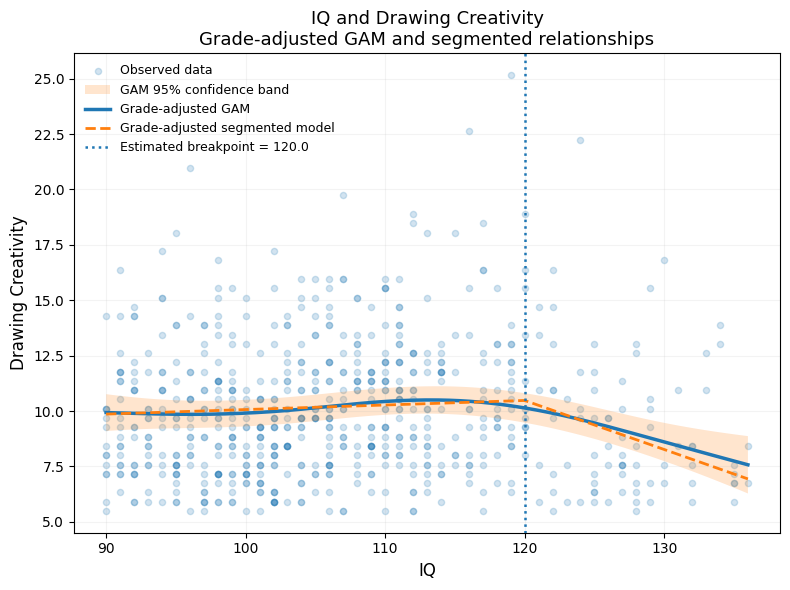

Saved: CRJ_Drawing_Creativity_IQ_Relationship.png

Creating figure: Category Creativity


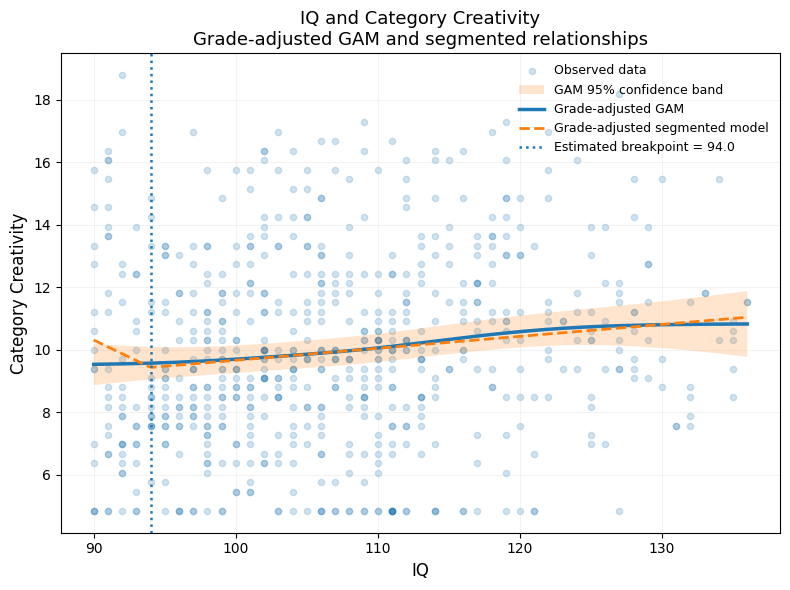

Saved: CRJ_Category_Creativity_IQ_Relationship.png

Creating figure: Total Creativity


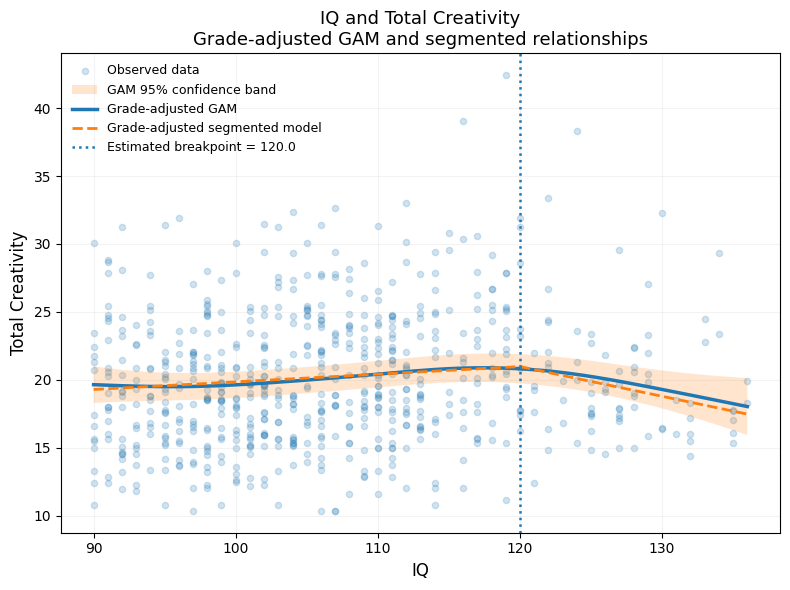

Saved: CRJ_Total_Creativity_IQ_Relationship.png

STEP 5A COMPLETED
Created 3 separate high-resolution figures and saved their underlying prediction data.


In [72]:
# ============================================================
# STEP 5A — PUBLICATION-QUALITY IQ–CREATIVITY FIGURES
#
# Each figure contains:
#   • Observed data
#   • Grade-adjusted GAM marginal curve
#   • Approximate 95% confidence band
#   • Grade-adjusted segmented curve
#   • Estimated breakpoint
#
# Three SEPARATE figures are produced:
#   1. Drawing Creativity
#   2. Category Creativity
#   3. Total Creativity
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------

# IQ grid for smooth predictions
iq_grid = np.linspace(
    model_data["IQ"].min(),
    model_data["IQ"].max(),
    250
)

# Observed Grade distribution
grade_values = (
    model_data["Grade"]
    .value_counts(normalize=True)
    .sort_index()
)

print("=" * 75)
print("STEP 5A — GRADE-ADJUSTED RELATIONSHIP FIGURES")
print("=" * 75)

print("\nObserved Grade weights:")
print(grade_values.round(3))


# ------------------------------------------------------------
# 2. STORAGE FOR MARGINAL CURVES
# ------------------------------------------------------------

marginal_curve_store = {}


# ------------------------------------------------------------
# 3. LOOP THROUGH OUTCOMES
# ------------------------------------------------------------

for label, outcome in outcomes.items():

    print("\nCreating figure:", label)

    gam = gam_models[label]

    seg_info = segmented_models[label]

    seg_model = seg_info["model"]

    breakpoint = seg_info["breakpoint"]


    # ========================================================
    # A. GAM MARGINAL PREDICTIONS
    #
    # Predict at every IQ value for every observed Grade,
    # then average according to the observed Grade distribution.
    # ========================================================

    gam_predictions_by_grade = []
    gam_lower_by_grade = []
    gam_upper_by_grade = []
    weights = []


    for grade, weight in grade_values.items():

        X_grid = np.column_stack([
            iq_grid,
            np.repeat(
                grade,
                len(iq_grid)
            )
        ])

        # GAM fitted values
        pred = gam.predict(
            X_grid
        )

        # pyGAM prediction intervals
        intervals = gam.confidence_intervals(
            X_grid,
            width=0.95
        )

        gam_predictions_by_grade.append(
            pred
        )

        gam_lower_by_grade.append(
            intervals[:, 0]
        )

        gam_upper_by_grade.append(
            intervals[:, 1]
        )

        weights.append(
            weight
        )


    # Convert to arrays
    gam_predictions_by_grade = np.asarray(
        gam_predictions_by_grade
    )

    gam_lower_by_grade = np.asarray(
        gam_lower_by_grade
    )

    gam_upper_by_grade = np.asarray(
        gam_upper_by_grade
    )

    weights = np.asarray(
        weights
    )


    # Weighted marginal GAM prediction
    gam_marginal = np.average(
        gam_predictions_by_grade,
        axis=0,
        weights=weights
    )

    # Approximate marginal confidence limits
    gam_lower = np.average(
        gam_lower_by_grade,
        axis=0,
        weights=weights
    )

    gam_upper = np.average(
        gam_upper_by_grade,
        axis=0,
        weights=weights
    )


    # ========================================================
    # B. SEGMENTED MARGINAL PREDICTIONS
    #
    # Same idea: predict at every IQ × Grade combination
    # and average using observed Grade weights.
    # ========================================================

    segmented_predictions_by_grade = []


    for grade, weight in grade_values.items():

        prediction_data = pd.DataFrame({
            "IQ": iq_grid,
            "Grade": grade
        })

        prediction_data["IQ_above"] = (
            np.maximum(
                0,
                prediction_data["IQ"]
                - breakpoint
            )
        )

        seg_pred = seg_model.predict(
            prediction_data
        )

        segmented_predictions_by_grade.append(
            np.asarray(seg_pred)
        )


    segmented_predictions_by_grade = np.asarray(
        segmented_predictions_by_grade
    )

    segmented_marginal = np.average(
        segmented_predictions_by_grade,
        axis=0,
        weights=weights
    )


    # ========================================================
    # C. STORE CURVES
    # ========================================================

    marginal_curve_store[label] = pd.DataFrame({

        "IQ":
            iq_grid,

        "GAM":
            gam_marginal,

        "GAM_Lower95":
            gam_lower,

        "GAM_Upper95":
            gam_upper,

        "Segmented":
            segmented_marginal
    })


    # ========================================================
    # D. FIGURE
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )


    # --------------------------------------------------------
    # Raw observations
    # --------------------------------------------------------

    ax.scatter(
        model_data["IQ"],
        model_data[outcome],
        alpha=0.20,
        s=20,
        label="Observed data"
    )


    # --------------------------------------------------------
    # GAM 95% confidence band
    # --------------------------------------------------------

    ax.fill_between(
        iq_grid,
        gam_lower,
        gam_upper,
        alpha=0.20,
        label="GAM 95% confidence band"
    )


    # --------------------------------------------------------
    # GAM marginal curve
    # --------------------------------------------------------

    ax.plot(
        iq_grid,
        gam_marginal,
        linewidth=2.5,
        label="Grade-adjusted GAM"
    )


    # --------------------------------------------------------
    # Segmented marginal curve
    # --------------------------------------------------------

    ax.plot(
        iq_grid,
        segmented_marginal,
        linewidth=2.0,
        linestyle="--",
        label="Grade-adjusted segmented model"
    )


    # --------------------------------------------------------
    # Breakpoint
    # --------------------------------------------------------

    ax.axvline(
        breakpoint,
        linestyle=":",
        linewidth=1.8,
        label=f"Estimated breakpoint = {breakpoint:.1f}"
    )


    # ========================================================
    # E. LABELS
    # ========================================================

    ax.set_xlabel(
        "IQ",
        fontsize=12
    )

    ax.set_ylabel(
        label,
        fontsize=12
    )

    ax.set_title(
        f"IQ and {label}\n"
        "Grade-adjusted GAM and segmented relationships",
        fontsize=13
    )

    ax.legend(
        frameon=False,
        fontsize=9
    )

    ax.grid(
        alpha=0.15
    )

    fig.tight_layout()


    # ========================================================
    # F. SAVE HIGH-RESOLUTION FIGURE
    # ========================================================

    safe_name = (
        label
        .replace(" ", "_")
    )

    filename = (
        f"CRJ_{safe_name}_IQ_Relationship.png"
    )

    fig.savefig(
        filename,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: {filename}"
    )


# ------------------------------------------------------------
# 4. SAVE NUMERICAL CURVE DATA
# ------------------------------------------------------------

for label, curve_data in marginal_curve_store.items():

    safe_name = (
        label
        .replace(" ", "_")
    )

    curve_data.to_csv(
        f"CRJ_{safe_name}_Curve_Data.csv",
        index=False
    )


print("\n" + "=" * 75)
print("STEP 5A COMPLETED")
print("=" * 75)

print(
    "Created 3 separate high-resolution figures "
    "and saved their underlying prediction data."
)

STEP 6A — RANDOM FOREST + PDP/ICE FOR IQ

---------------------------------------------------------------------------
Drawing Creativity
---------------------------------------------------------------------------
N = 682 | Test R² = 0.091 | RMSE = 2.829 | MAE = 2.168


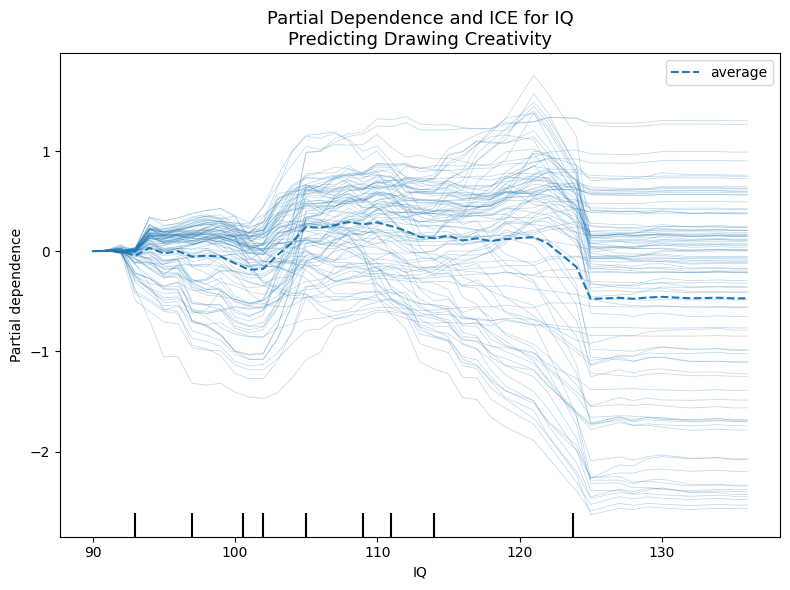

Saved: CRJ_PDP_ICE_IQ_Drawing_Creativity.png

---------------------------------------------------------------------------
Category Creativity
---------------------------------------------------------------------------
N = 682 | Test R² = 0.036 | RMSE = 2.975 | MAE = 2.339


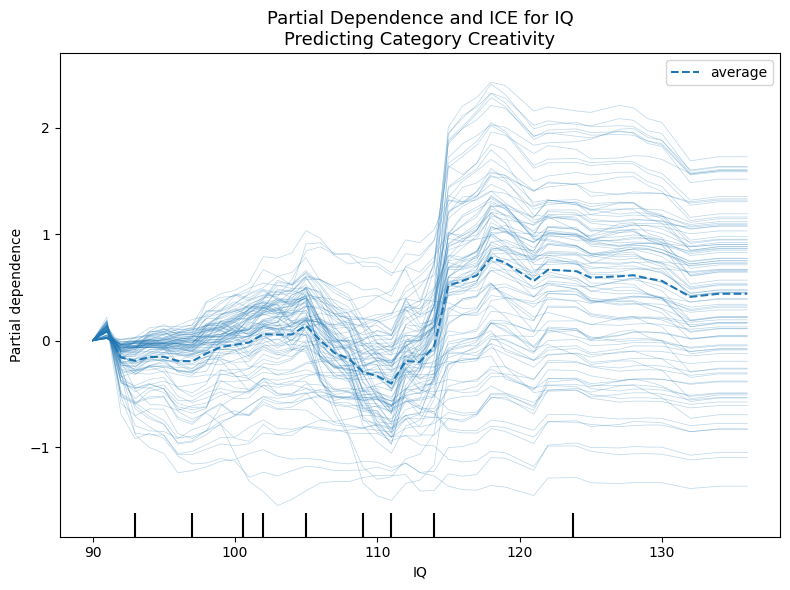

Saved: CRJ_PDP_ICE_IQ_Category_Creativity.png

---------------------------------------------------------------------------
Total Creativity
---------------------------------------------------------------------------
N = 682 | Test R² = 0.093 | RMSE = 4.542 | MAE = 3.502


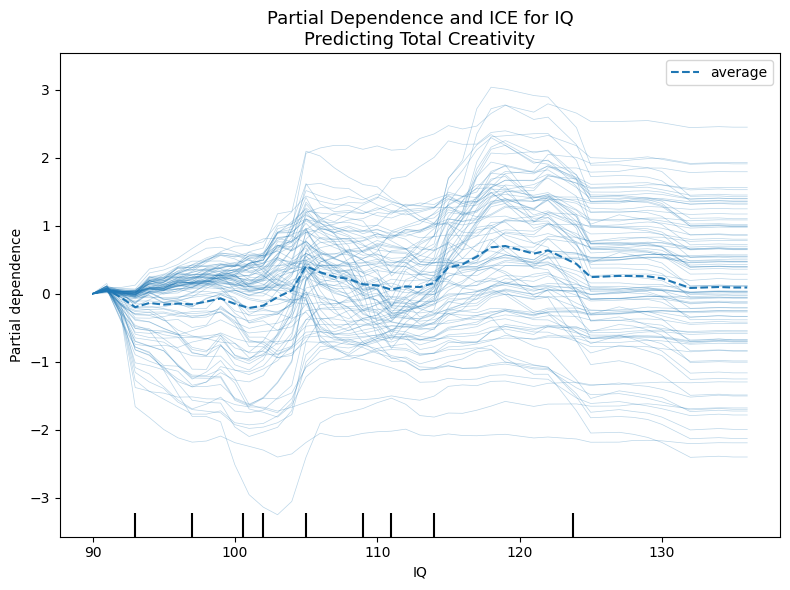

Saved: CRJ_PDP_ICE_IQ_Total_Creativity.png

RANDOM FOREST TEST-SET PERFORMANCE


,Outcome,N,Train_N,Test_N,Test_R2,Test_RMSE,Test_MAE
0,Drawing Creativity,682,545,137,0.091,2.829,2.168
1,Category Creativity,682,545,137,0.036,2.975,2.339
2,Total Creativity,682,545,137,0.093,4.542,3.502



STEP 6A COMPLETED
Created PDP + ICE figures for IQ for all three creativity outcomes.

The fitted RF models and test sets are retained for the next SHAP analysis.


In [73]:
# ============================================================
# STEP 6A — MACHINE-LEARNING INTERPRETABILITY
# RANDOM FOREST + PDP / ICE FOR IQ
#
# Purpose:
#   1. Fit a reproducible Random Forest for each creativity outcome
#   2. Evaluate out-of-sample predictive performance
#   3. Produce Partial Dependence (PDP) and ICE plots for IQ
#
# NOTE:
# PDP = average predicted relationship between IQ and creativity
# ICE = participant-level predicted relationships
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)
from sklearn.inspection import PartialDependenceDisplay


# ------------------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------------------

RANDOM_SEED = 42
TEST_SIZE = 0.20

# Predictors available in the main manuscript dataset.
# IQ is the focal predictor.
ml_predictors = [
    "IQ",
    "Grade",
    "Age",
    "Gender",
    "Parerating",
    "Teachrating"
]

ml_outcomes = {
    "Drawing Creativity": "PCAdrawstn",
    "Category Creativity": "PCAcatestn",
    "Total Creativity": "PCASumStn"
}


# ------------------------------------------------------------
# 2. STORAGE
# ------------------------------------------------------------

rf_models = {}
rf_test_sets = {}
rf_results = []


print("=" * 75)
print("STEP 6A — RANDOM FOREST + PDP/ICE FOR IQ")
print("=" * 75)


# ------------------------------------------------------------
# 3. LOOP THROUGH OUTCOMES
# ------------------------------------------------------------

for label, outcome in ml_outcomes.items():

    print("\n" + "-" * 75)
    print(label)
    print("-" * 75)

    # ========================================================
    # A. CREATE COMPLETE ANALYSIS DATA
    # ========================================================

    required_vars = ml_predictors + [outcome]

    ml_data = (
        analysis[required_vars]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .copy()
    )

    X = ml_data[ml_predictors]
    y = ml_data[outcome]


    # ========================================================
    # B. TRAIN / TEST SPLIT
    # ========================================================

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED
    )


    # ========================================================
    # C. RANDOM FOREST
    # ========================================================

    rf = RandomForestRegressor(
        n_estimators=500,
        min_samples_leaf=5,
        max_features="sqrt",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    rf.fit(
        X_train,
        y_train
    )

    y_pred = rf.predict(
        X_test
    )


    # ========================================================
    # D. TEST-SET PERFORMANCE
    # ========================================================

    test_r2 = r2_score(
        y_test,
        y_pred
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    test_mae = mean_absolute_error(
        y_test,
        y_pred
    )


    rf_results.append({
        "Outcome": label,
        "N": len(ml_data),
        "Train_N": len(X_train),
        "Test_N": len(X_test),
        "Test_R2": test_r2,
        "Test_RMSE": test_rmse,
        "Test_MAE": test_mae
    })


    # Save objects for later SHAP analysis
    rf_models[label] = rf

    rf_test_sets[label] = {
        "X_train": X_train.copy(),
        "X_test": X_test.copy(),
        "y_train": y_train.copy(),
        "y_test": y_test.copy()
    }


    print(
        f"N = {len(ml_data)} | "
        f"Test R² = {test_r2:.3f} | "
        f"RMSE = {test_rmse:.3f} | "
        f"MAE = {test_mae:.3f}"
    )


    # ========================================================
    # E. PDP + ICE FOR IQ
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    PartialDependenceDisplay.from_estimator(
        rf,
        X_test,
        features=["IQ"],

        # "both" overlays PDP and ICE
        kind="both",

        # Center ICE curves so differences in shape
        # are easier to see
        centered=True,

        # Limit number of ICE curves for readability
        subsample=100,

        random_state=RANDOM_SEED,

        # Reasonable resolution across IQ
        grid_resolution=50,

        ax=ax
    )


    # ========================================================
    # F. FIGURE LABELS
    # ========================================================

    ax.set_title(
        f"Partial Dependence and ICE for IQ\n"
        f"Predicting {label}",
        fontsize=13
    )

    ax.set_xlabel(
        "IQ",
        fontsize=12
    )

    ax.set_ylabel(
        "Centered predicted creativity",
        fontsize=12
    )

    fig.tight_layout()


    # ========================================================
    # G. SAVE HIGH-RESOLUTION FIGURE
    # ========================================================

    safe_name = label.replace(
        " ",
        "_"
    )

    filename = (
        f"CRJ_PDP_ICE_IQ_{safe_name}.png"
    )

    fig.savefig(
        filename,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: {filename}"
    )


# ------------------------------------------------------------
# 4. MODEL PERFORMANCE TABLE
# ------------------------------------------------------------

rf_performance = pd.DataFrame(
    rf_results
)

print("\n" + "=" * 75)
print("RANDOM FOREST TEST-SET PERFORMANCE")
print("=" * 75)

display(
    rf_performance.style.format({
        "Test_R2": "{:.3f}",
        "Test_RMSE": "{:.3f}",
        "Test_MAE": "{:.3f}"
    })
)


# ------------------------------------------------------------
# 5. SAVE PERFORMANCE TABLE
# ------------------------------------------------------------

rf_performance.to_csv(
    "CRJ_RandomForest_Performance.csv",
    index=False
)


print("\n" + "=" * 75)
print("STEP 6A COMPLETED")
print("=" * 75)

print(
    "Created PDP + ICE figures for IQ "
    "for all three creativity outcomes."
)

print(
    "\nThe fitted RF models and test sets are retained "
    "for the next SHAP analysis."
)

STEP 7 — SHAP ANALYSIS

---------------------------------------------------------------------------
Drawing Creativity
---------------------------------------------------------------------------


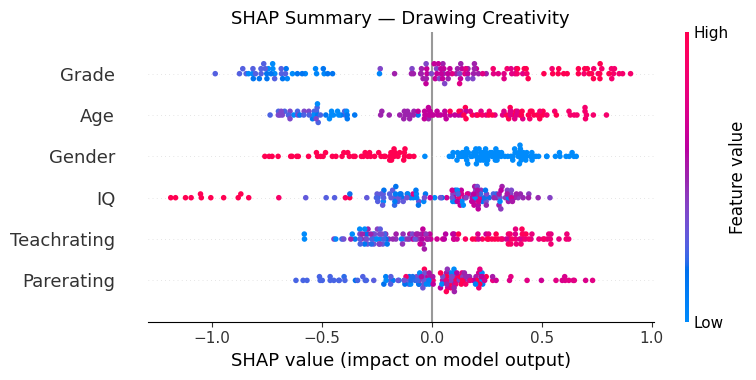

Saved: CRJ_SHAP_Summary_Drawing_Creativity.png


<Figure size 800x600 with 0 Axes>

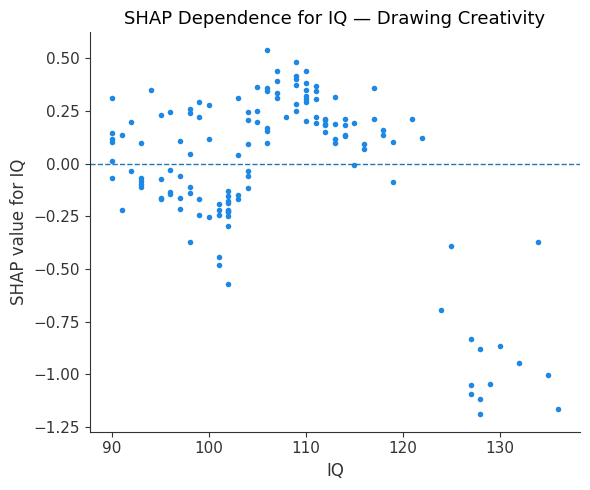

Saved: CRJ_SHAP_IQ_Drawing_Creativity.png

---------------------------------------------------------------------------
Category Creativity
---------------------------------------------------------------------------


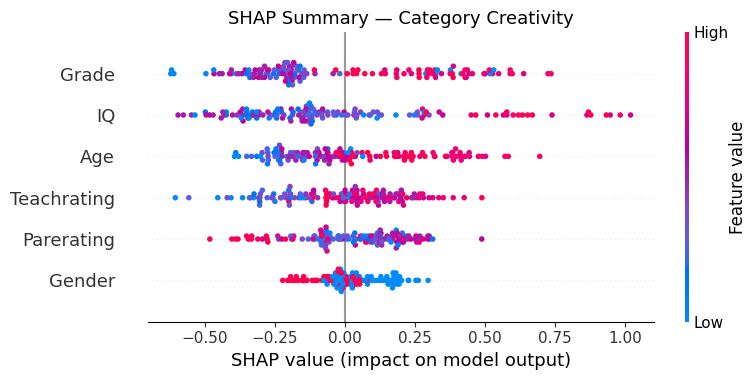

Saved: CRJ_SHAP_Summary_Category_Creativity.png


<Figure size 800x600 with 0 Axes>

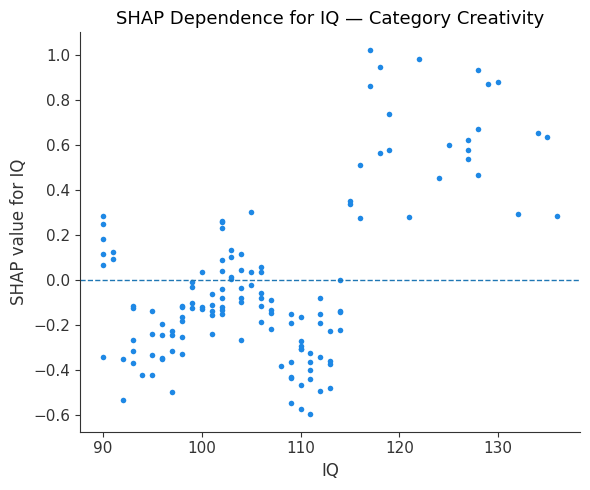

Saved: CRJ_SHAP_IQ_Category_Creativity.png

---------------------------------------------------------------------------
Total Creativity
---------------------------------------------------------------------------


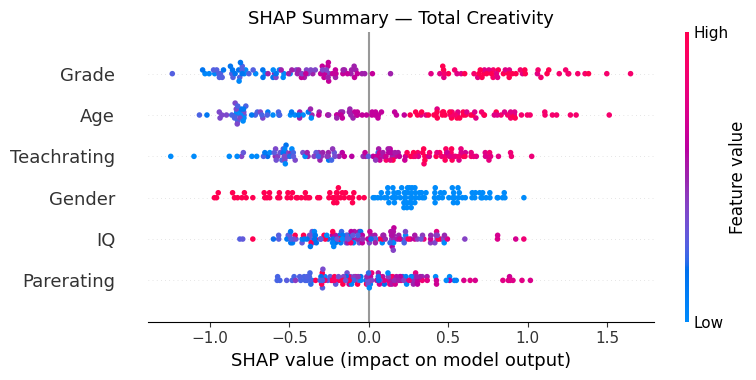

Saved: CRJ_SHAP_Summary_Total_Creativity.png


<Figure size 800x600 with 0 Axes>

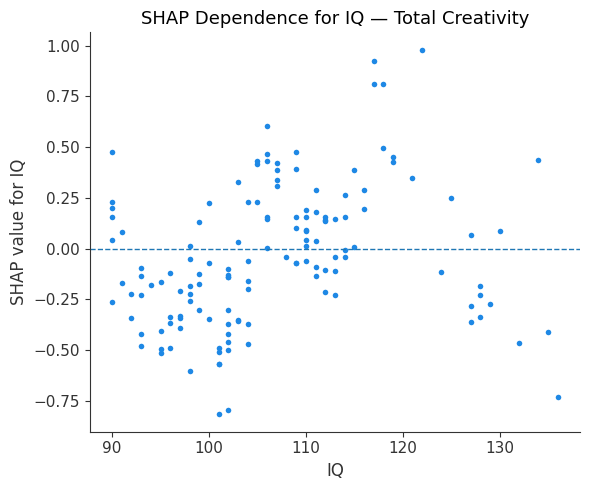

Saved: CRJ_SHAP_IQ_Total_Creativity.png

MEAN ABSOLUTE SHAP IMPORTANCE


,Outcome,Feature,Mean_Abs_SHAP,Rank
0,Category Creativity,Grade,0.2944,1
1,Category Creativity,IQ,0.2910,2
2,Category Creativity,Age,0.2027,3
3,Category Creativity,Teachrating,0.1672,4
4,Category Creativity,Parerating,0.1519,5
5,Category Creativity,Gender,0.0818,6
6,Drawing Creativity,Grade,0.4321,1
7,Drawing Creativity,Age,0.3619,2
8,Drawing Creativity,Gender,0.3234,3
9,Drawing Creativity,IQ,0.2840,4



SHAP IMPORTANCE BY OUTCOME


Outcome,Category Creativity,Drawing Creativity,Total Creativity
Feature,,,
Age,0.2027,0.3619,0.5706
Gender,0.0818,0.3234,0.4080
Grade,0.2944,0.4321,0.6520
IQ,0.2910,0.2840,0.2817
Parerating,0.1519,0.2035,0.2711
Teachrating,0.1672,0.2686,0.4220



IQ SHAP IMPORTANCE


,Outcome,Mean_Abs_SHAP,Rank
0,Category Creativity,0.2910,2
1,Drawing Creativity,0.2840,4
2,Total Creativity,0.2817,5



STEP 7 COMPLETED
Created:
• 3 SHAP summary plots
• 3 IQ SHAP dependence plots
• Overall SHAP importance table
• IQ-specific SHAP importance table


In [74]:
# ============================================================
# STEP 7 — SHAP ANALYSIS
# RANDOM FOREST INTERPRETABILITY
#
# Uses the exact RF models and test sets from Step 6A.
#
# Outputs:
#   1. Mean absolute SHAP importance table
#   2. SHAP summary/beeswarm plot for each outcome
#   3. SHAP dependence plot for IQ for each outcome
# ============================================================

# Install SHAP if necessary
try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


print("=" * 75)
print("STEP 7 — SHAP ANALYSIS")
print("=" * 75)


# ------------------------------------------------------------
# 1. STORAGE
# ------------------------------------------------------------

shap_importance_results = []

shap_values_store = {}
shap_explainers = {}


# ------------------------------------------------------------
# 2. LOOP THROUGH OUTCOMES
# ------------------------------------------------------------

for label in ml_outcomes.keys():

    print("\n" + "-" * 75)
    print(label)
    print("-" * 75)


    # ========================================================
    # A. RETRIEVE EXISTING MODEL AND TEST DATA
    # ========================================================

    rf = rf_models[label]

    X_test = (
        rf_test_sets[label]["X_test"]
        .copy()
    )


    # ========================================================
    # B. TREE SHAP
    # ========================================================

    explainer = shap.TreeExplainer(
        rf
    )

    shap_values = explainer.shap_values(
        X_test
    )

    shap_explainers[label] = explainer
    shap_values_store[label] = shap_values


    # ========================================================
    # C. MEAN ABSOLUTE SHAP IMPORTANCE
    # ========================================================

    mean_abs_shap = np.abs(
        shap_values
    ).mean(axis=0)


    for feature, importance in zip(
        X_test.columns,
        mean_abs_shap
    ):

        shap_importance_results.append({
            "Outcome": label,
            "Feature": feature,
            "Mean_Abs_SHAP": importance
        })


    # ========================================================
    # D. SHAP SUMMARY / BEESWARM
    # ========================================================

    plt.figure(
        figsize=(8, 6)
    )

    shap.summary_plot(
        shap_values,
        X_test,
        show=False,
        max_display=len(X_test.columns)
    )

    plt.title(
        f"SHAP Summary — {label}",
        fontsize=13
    )

    plt.tight_layout()


    safe_name = label.replace(
        " ",
        "_"
    )

    filename_summary = (
        f"CRJ_SHAP_Summary_{safe_name}.png"
    )

    plt.savefig(
        filename_summary,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: {filename_summary}"
    )


    # ========================================================
    # E. SHAP DEPENDENCE PLOT — IQ
    # ========================================================

    plt.figure(
        figsize=(8, 6)
    )

    shap.dependence_plot(
        "IQ",
        shap_values,
        X_test,
        interaction_index=None,
        show=False
    )

    plt.title(
        f"SHAP Dependence for IQ — {label}",
        fontsize=13
    )

    plt.xlabel(
        "IQ",
        fontsize=12
    )

    plt.ylabel(
        "SHAP value for IQ",
        fontsize=12
    )

    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    plt.tight_layout()


    filename_dependence = (
        f"CRJ_SHAP_IQ_{safe_name}.png"
    )

    plt.savefig(
        filename_dependence,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    print(
        f"Saved: {filename_dependence}"
    )


# ------------------------------------------------------------
# 3. CREATE SHAP IMPORTANCE TABLE
# ------------------------------------------------------------

shap_importance = pd.DataFrame(
    shap_importance_results
)


# Rank predictors separately within each outcome
shap_importance["Rank"] = (
    shap_importance
    .groupby("Outcome")[
        "Mean_Abs_SHAP"
    ]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)


shap_importance = (
    shap_importance
    .sort_values(
        ["Outcome", "Rank"]
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 75)
print("MEAN ABSOLUTE SHAP IMPORTANCE")
print("=" * 75)

display(
    shap_importance.style.format({
        "Mean_Abs_SHAP": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 4. CREATE COMPACT RANKING TABLE
# ------------------------------------------------------------

shap_ranking_table = (
    shap_importance
    .pivot(
        index="Feature",
        columns="Outcome",
        values="Mean_Abs_SHAP"
    )
)


print("\n" + "=" * 75)
print("SHAP IMPORTANCE BY OUTCOME")
print("=" * 75)

display(
    shap_ranking_table.style.format(
        "{:.4f}"
    )
)


# ------------------------------------------------------------
# 5. SPECIFICALLY EXTRACT IQ IMPORTANCE
# ------------------------------------------------------------

iq_shap_summary = (
    shap_importance[
        shap_importance["Feature"] == "IQ"
    ]
    [
        [
            "Outcome",
            "Mean_Abs_SHAP",
            "Rank"
        ]
    ]
    .reset_index(drop=True)
)


print("\n" + "=" * 75)
print("IQ SHAP IMPORTANCE")
print("=" * 75)

display(
    iq_shap_summary.style.format({
        "Mean_Abs_SHAP": "{:.4f}"
    })
)


# ------------------------------------------------------------
# 6. SAVE TABLES
# ------------------------------------------------------------

shap_importance.to_csv(
    "CRJ_SHAP_Importance.csv",
    index=False
)

iq_shap_summary.to_csv(
    "CRJ_SHAP_IQ_Importance.csv",
    index=False
)


# ------------------------------------------------------------
# 7. FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("STEP 7 COMPLETED")
print("=" * 75)

print(
    "Created:\n"
    "• 3 SHAP summary plots\n"
    "• 3 IQ SHAP dependence plots\n"
    "• Overall SHAP importance table\n"
    "• IQ-specific SHAP importance table"
)

In [75]:
# ============================================================
# FINAL CTONI-2 RELIABILITY ANALYSIS
#
# Confirmed subtest order from Dr. Ahmed:
#
# Block 1 = Pictorial Analogies   (PA)
# Block 2 = Geometric Analogies   (GA)
# Block 3 = Pictorial Categories  (PC)
# Block 4 = Geometric Categories  (GC)
# Block 5 = Pictorial Sequences   (PS)
# Block 6 = Geometric Sequences   (GS)
#
# Composite item sets:
# PCI = PA + PC + PS
# GCI = GA + GC + GS
# Overall CTONI = all six subtests
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. RENAME THE SIX CONFIRMED SUBTEST BLOCKS
# ------------------------------------------------------------

ctoni_named_blocks = {

    "Pictorial Analogies (PA)":
        ctoni_blocks["Block1"],

    "Geometric Analogies (GA)":
        ctoni_blocks["Block2"],

    "Pictorial Categories (PC)":
        ctoni_blocks["Block3"],

    "Geometric Categories (GC)":
        ctoni_blocks["Block4"],

    "Pictorial Sequences (PS)":
        ctoni_blocks["Block5"],

    "Geometric Sequences (GS)":
        ctoni_blocks["Block6"]
}


# ------------------------------------------------------------
# 2. DEFINE COMPOSITE ITEM SETS
# ------------------------------------------------------------

PCI_items = (
    ctoni_named_blocks["Pictorial Analogies (PA)"]
    +
    ctoni_named_blocks["Pictorial Categories (PC)"]
    +
    ctoni_named_blocks["Pictorial Sequences (PS)"]
)

GCI_items = (
    ctoni_named_blocks["Geometric Analogies (GA)"]
    +
    ctoni_named_blocks["Geometric Categories (GC)"]
    +
    ctoni_named_blocks["Geometric Sequences (GS)"]
)

overall_ctoni_items = (
    PCI_items + GCI_items
)


print("=" * 75)
print("CTONI-2 ITEM STRUCTURE")
print("=" * 75)

print(
    "PA items:",
    len(ctoni_named_blocks["Pictorial Analogies (PA)"])
)

print(
    "GA items:",
    len(ctoni_named_blocks["Geometric Analogies (GA)"])
)

print(
    "PC items:",
    len(ctoni_named_blocks["Pictorial Categories (PC)"])
)

print(
    "GC items:",
    len(ctoni_named_blocks["Geometric Categories (GC)"])
)

print(
    "PS items:",
    len(ctoni_named_blocks["Pictorial Sequences (PS)"])
)

print(
    "GS items:",
    len(ctoni_named_blocks["Geometric Sequences (GS)"])
)

print("PCI item set:", len(PCI_items))
print("GCI item set:", len(GCI_items))
print("Overall item set:", len(overall_ctoni_items))


# ------------------------------------------------------------
# 3. RELIABILITY FUNCTION
#
# For dichotomous 0/1 items:
# Cronbach's alpha = KR-20
#
# Invalid responses are converted to missing.
# Complete cases are used within each scale.
# ------------------------------------------------------------

def ctoni_kr20(df, cols):

    x = (
        df[cols]
        .apply(
            pd.to_numeric,
            errors="coerce"
        )
    )

    # Only legitimate CTONI responses
    x = x.where(
        x.isin([0, 1])
    )

    # Complete cases within this scale
    complete = x.dropna()

    n = len(complete)
    k = complete.shape[1]

    if n < 2 or k < 2:

        return {
            "N": n,
            "Items": k,
            "KR20_Alpha": np.nan
        }

    item_variances = complete.var(
        axis=0,
        ddof=1
    )

    total_score = complete.sum(
        axis=1
    )

    total_variance = total_score.var(
        ddof=1
    )

    if total_variance == 0:

        alpha = np.nan

    else:

        alpha = (
            k / (k - 1)
        ) * (
            1
            -
            item_variances.sum()
            / total_variance
        )

    return {
        "N": n,
        "Items": k,
        "KR20_Alpha": alpha
    }


# ------------------------------------------------------------
# 4. CALCULATE SIX SUBTEST RELIABILITIES
# ------------------------------------------------------------

reliability_results = []


for scale_name, cols in ctoni_named_blocks.items():

    result = ctoni_kr20(
        ctoni,
        cols
    )

    reliability_results.append({

        "Scale":
            scale_name,

        "Items":
            result["Items"],

        "N":
            result["N"],

        "KR20_Alpha":
            result["KR20_Alpha"]
    })


# ------------------------------------------------------------
# 5. PCI RELIABILITY
# ------------------------------------------------------------

pci_result = ctoni_kr20(
    ctoni,
    PCI_items
)

reliability_results.append({

    "Scale":
        "Pictorial Composite item set (PCI)",

    "Items":
        pci_result["Items"],

    "N":
        pci_result["N"],

    "KR20_Alpha":
        pci_result["KR20_Alpha"]
})


# ------------------------------------------------------------
# 6. GCI RELIABILITY
# ------------------------------------------------------------

gci_result = ctoni_kr20(
    ctoni,
    GCI_items
)

reliability_results.append({

    "Scale":
        "Geometric Composite item set (GCI)",

    "Items":
        gci_result["Items"],

    "N":
        gci_result["N"],

    "KR20_Alpha":
        gci_result["KR20_Alpha"]
})


# ------------------------------------------------------------
# 7. OVERALL CTONI RELIABILITY
# ------------------------------------------------------------

overall_result = ctoni_kr20(
    ctoni,
    overall_ctoni_items
)

reliability_results.append({

    "Scale":
        "Overall CTONI-2 item set",

    "Items":
        overall_result["Items"],

    "N":
        overall_result["N"],

    "KR20_Alpha":
        overall_result["KR20_Alpha"]
})


# ------------------------------------------------------------
# 8. CREATE PUBLICATION-READY TABLE
# ------------------------------------------------------------

ctoni_final_reliability = pd.DataFrame(
    reliability_results
)


print("\n" + "=" * 75)
print("FINAL CTONI-2 INTERNAL CONSISTENCY RELIABILITY")
print("=" * 75)


display(
    ctoni_final_reliability.style.format({

        "KR20_Alpha":
            "{:.3f}"
    })
)


# ------------------------------------------------------------
# 9. CREATE MANUSCRIPT VERSION
#
# Shorter labels for eventual table.
# ------------------------------------------------------------

ctoni_manuscript_table = (
    ctoni_final_reliability.copy()
)

ctoni_manuscript_table["Scale"] = (
    ctoni_manuscript_table["Scale"]
    .replace({

        "Pictorial Composite item set (PCI)":
            "Pictorial Composite (PCI)",

        "Geometric Composite item set (GCI)":
            "Geometric Composite (GCI)",

        "Overall CTONI-2 item set":
            "Overall CTONI-2"
    })
)


print("\n" + "=" * 75)
print("CTONI-2 — MANUSCRIPT TABLE")
print("=" * 75)


display(
    ctoni_manuscript_table.style.format({

        "KR20_Alpha":
            "{:.3f}"
    })
)


# ------------------------------------------------------------
# 10. UPDATE GRADE-SPECIFIC RELIABILITY LABELS
#
# Uses the grade-specific table already calculated earlier.
# ------------------------------------------------------------

block_name_map = {

    "Block1":
        "Pictorial Analogies (PA)",

    "Block2":
        "Geometric Analogies (GA)",

    "Block3":
        "Pictorial Categories (PC)",

    "Block4":
        "Geometric Categories (GC)",

    "Block5":
        "Pictorial Sequences (PS)",

    "Block6":
        "Geometric Sequences (GS)"
}


if "ctoni_grade_reliability" in globals():

    ctoni_grade_reliability_final = (
        ctoni_grade_reliability.copy()
    )

    ctoni_grade_reliability_final[
        "Scale"
    ] = (
        ctoni_grade_reliability_final[
            "Scale"
        ]
        .replace(
            block_name_map
        )
    )

    print("\n" + "=" * 75)
    print("GRADE-SPECIFIC CTONI-2 RELIABILITY")
    print("=" * 75)

    grade_alpha_final = (
        ctoni_grade_reliability_final
        .pivot(
            index="Grade",
            columns="Scale",
            values="KR20_Alpha"
        )
    )

    display(
        grade_alpha_final.style.format(
            "{:.3f}"
        )
    )

else:

    print(
        "\nGrade-specific reliability object "
        "'ctoni_grade_reliability' was not found."
    )


# ------------------------------------------------------------
# 11. SAVE FINAL TABLES
# ------------------------------------------------------------

ctoni_manuscript_table.to_csv(
    "CRJ_Final_CTONI_Reliability.csv",
    index=False
)


if "ctoni_grade_reliability_final" in globals():

    ctoni_grade_reliability_final.to_csv(
        "CRJ_Final_CTONI_Reliability_by_Grade.csv",
        index=False
    )


print("\n" + "=" * 75)
print("CTONI-2 RELIABILITY FINALIZATION COMPLETED")
print("=" * 75)

print(
    "Saved:\n"
    "• CRJ_Final_CTONI_Reliability.csv\n"
    "• CRJ_Final_CTONI_Reliability_by_Grade.csv "
    "(if grade-specific results were available)"
)

CTONI-2 ITEM STRUCTURE
PA items: 25
GA items: 25
PC items: 25
GC items: 25
PS items: 25
GS items: 25
PCI item set: 75
GCI item set: 75
Overall item set: 150

FINAL CTONI-2 INTERNAL CONSISTENCY RELIABILITY


,Scale,Items,N,KR20_Alpha
0,Pictorial Analogies (PA),25,1587,0.960
1,Geometric Analogies (GA),25,1588,0.967
2,Pictorial Categories (PC),25,1588,0.959
3,Geometric Categories (GC),25,1586,0.969
4,Pictorial Sequences (PS),25,1587,0.968
5,Geometric Sequences (GS),25,1588,0.968
6,Pictorial Composite item set (PCI),75,1586,0.986
7,Geometric Composite item set (GCI),75,1586,0.988
8,Overall CTONI-2 item set,150,1584,0.993



CTONI-2 — MANUSCRIPT TABLE


,Scale,Items,N,KR20_Alpha
0,Pictorial Analogies (PA),25,1587,0.960
1,Geometric Analogies (GA),25,1588,0.967
2,Pictorial Categories (PC),25,1588,0.959
3,Geometric Categories (GC),25,1586,0.969
4,Pictorial Sequences (PS),25,1587,0.968
5,Geometric Sequences (GS),25,1588,0.968
6,Pictorial Composite (PCI),75,1586,0.986
7,Geometric Composite (GCI),75,1586,0.988
8,Overall CTONI-2,150,1584,0.993



GRADE-SPECIFIC CTONI-2 RELIABILITY


Scale,Geometric Analogies (GA),Geometric Categories (GC),Geometric Sequences (GS),Pictorial Analogies (PA),Pictorial Categories (PC),Pictorial Sequences (PS)
Grade,,,,,,
1,0.915,0.882,0.880,0.859,0.870,0.847
2,0.894,0.874,0.879,0.875,0.791,0.905
3,0.913,0.864,0.885,0.853,0.816,0.876
4,0.851,0.874,0.862,0.855,0.828,0.890
5,0.932,0.843,0.891,0.912,0.837,0.871
6,0.925,0.885,0.902,0.905,0.886,0.846
7,0.907,0.832,0.893,0.884,0.867,0.817
8,0.910,0.872,0.870,0.896,0.854,0.839
9,0.930,0.858,0.922,0.907,0.887,0.887



CTONI-2 RELIABILITY FINALIZATION COMPLETED
Saved:
• CRJ_Final_CTONI_Reliability.csv
• CRJ_Final_CTONI_Reliability_by_Grade.csv (if grade-specific results were available)
